# NLP and Deep Learning for Text Classification in Medical Diagnosis

## Research Question

RQ1: What is the effectiveness of the NLP algorithm in classifying patient symptoms from the text data on the population level?
- **H10**: Text analysis of patient symptoms results in insufficient precision and recall for provider decision support.
- **H1a**: Text analysis of patient symptoms results in precision and recall sufficient for provider decision support.

## Overview

This notebook implements a complete text classification pipeline to analyze medical symptom descriptions and classify them into appropriate diagnostic categories. We'll evaluate multiple NLP approaches and deep learning models to determine which provides the best performance for medical symptom classification.

## 1. Environment Setup

First, we'll import all necessary libraries for our analysis. This includes data manipulation, visualization, NLP, and machine learning tools.

In [156]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import re
import string
import os
import warnings
from wordcloud import WordCloud
from PIL import Image

# NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer
from textblob import TextBlob
import textstat

# Machine learning libraries
import sklearn
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Deep learning libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, GlobalMaxPooling1D, Conv1D, MaxPooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

# Suppress warnings
warnings.filterwarnings('ignore')

# Download NLTK resources
try:
    nltk.data.find('tokenizers/punkt')
    nltk.data.find('corpora/stopwords')
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('punkt')
    nltk.download('stopwords')
    nltk.download('wordnet')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Configure visualization settings
plt.style.use('fivethirtyeight')
sns.set(style='whitegrid')

# Display versions of key libraries
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"TensorFlow version: {tf.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")

Pandas version: 2.0.2
NumPy version: 1.23.5
TensorFlow version: 2.12.0
Scikit-learn version: 1.0.2


[nltk_data] Downloading package punkt to C:\Users\S-C-R-E-
[nltk_data]     A-M\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\S-C-R-E-
[nltk_data]     A-M\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\S-C-R-E-
[nltk_data]     A-M\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## 2. Data Loading and Exploration

Now we'll load the dataset and explore its structure. We'll focus on the key fields for our analysis: 'phrase' (patient descriptions) and 'prompt' (diagnostic categories).

In [157]:
# Define the dataset path
data_path = r'G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\data\Medical Speech, Transcription, and Intent\overview-of-recordings.csv'

# Load the dataset
df = pd.read_csv(data_path)

# Define key fields for analysis as specified
key_fields = ['phrase', 'prompt']

# Display basic information about the dataset
print(f"Dataset shape: {df.shape}")
print(f"\nDataset columns: {df.columns.tolist()}")
print(f"\nKey fields for analysis: {key_fields}")

# Display the first few rows of the dataset focused on our key fields
print("\nSample data (first 5 rows):")
df[key_fields].head()

Dataset shape: (6661, 13)

Dataset columns: ['audio_clipping', 'audio_clipping:confidence', 'background_noise_audible', 'background_noise_audible:confidence', 'overall_quality_of_the_audio', 'quiet_speaker', 'quiet_speaker:confidence', 'speaker_id', 'file_download', 'file_name', 'phrase', 'prompt', 'writer_id']

Key fields for analysis: ['phrase', 'prompt']

Sample data (first 5 rows):


,phrase,prompt
0,When I remember her I feel down,Emotional pain
1,When I carry heavy things I feel like breaking...,Hair falling out
2,there is too much pain when i move my arm,Heart hurts
3,My son had his lip pierced and it is swollen a...,Infected wound
4,My muscles in my lower back are aching,Infected wound


### 2.1 Data Cleaning (Data Quality Check)

Check for missing values, duplicates, and other data quality issues in our key fields.

In [158]:
# Check for missing values in key fields
print("Missing values in key fields:")
print(df[key_fields].isna().sum())

# Check for duplicates in phrases
duplicates = df.duplicated(subset=['phrase']).sum()
print(f"\nDuplicate phrases: {duplicates}")

# Check class distribution (diagnostic categories)
print("\nClass distribution (top 10 diagnostic categories):")
class_distribution = df['prompt'].value_counts()
print(class_distribution.head(10))

# Calculate class imbalance statistics
total_classes = len(class_distribution)
print(f"\nTotal number of unique diagnostic categories: {total_classes}")

# Check statistics on text length
df['phrase_length'] = df['phrase'].str.len()
print("\nText length statistics:")
print(df['phrase_length'].describe())

# Remove temporary column
df.drop('phrase_length', axis=1, inplace=True)

Missing values in key fields:
phrase    0
prompt    0
dtype: int64

Duplicate phrases: 5955

Class distribution (top 10 diagnostic categories):
prompt
Acne              328
Shoulder pain     320
Joint pain        318
Infected wound    306
Knee pain         305
Cough             293
Feeling dizzy     283
Muscle pain       282
Heart hurts       273
Ear ache          270
Name: count, dtype: int64

Total number of unique diagnostic categories: 25

Text length statistics:
count    6661.000000
mean       50.026122
std        23.672184
min         9.000000
25%        33.000000
50%        45.000000
75%        61.000000
max       155.000000
Name: phrase_length, dtype: float64


### 2.2 Data Visualization

Visualize the class distribution and text characteristics to gain a better understanding of our dataset.

In [159]:
# Visualize class distribution (top 15 categories)
top_n = 15
top_categories = class_distribution.head(top_n).reset_index()
top_categories.columns = ['Category', 'Count']

fig = px.bar(top_categories, x='Category', y='Count', 
             title=f'Distribution of Top {top_n} Diagnostic Categories',
             color='Count', color_continuous_scale='viridis')
fig.update_layout(xaxis={'categoryorder':'total descending'})
fig.show()

# Calculate text length
df['text_length'] = df['phrase'].apply(len)
df['word_count'] = df['phrase'].apply(lambda x: len(str(x).split()))

# Visualize text length distribution
fig = make_subplots(rows=1, cols=2, 
                    subplot_titles=('Distribution of Text Length (Characters)', 
                                  'Distribution of Word Count'))

fig.add_trace(
    go.Histogram(x=df['text_length'], nbinsx=30, marker_color='blue'),
    row=1, col=1
)

fig.add_trace(
    go.Histogram(x=df['word_count'], nbinsx=30, marker_color='green'),
    row=1, col=2
)

fig.update_layout(height=500, width=1000, title_text="Text Length Analysis")
fig.show()

# Remove temporary columns
df.drop(['text_length', 'word_count'], axis=1, inplace=True)

## 3. Text Data Preprocessing

Transforming the cleaned text data into a format suitable for machine learning algorithms.

### 3.1 Define Basic Text Cleaning Function

**Purpose:** To clean the raw text data by converting it to lowercase, replacing contractions, removing special characters, and extra whitespaces.

In [160]:
def clean_text(text):
    """Basic text cleaning function"""
    if isinstance(text, str):  # Check if text is a string
        # Convert to lowercase
        text = text.lower()
        
        # Replace contractions
        text = re.sub(r"what's", "what is", text)
        text = re.sub(r"'s", " is", text)
        text = re.sub(r"'ve", " have", text)
        text = re.sub(r"can't", "cannot", text)
        text = re.sub(r"n't", " not", text)
        text = re.sub(r"'re", " are", text)
        text = re.sub(r"'d", " would", text)
        text = re.sub(r"'ll", " will", text)
        text = re.sub(r"'t", " not", text)
        
        # Remove special characters and digits
        text = re.sub(r"[^a-zA-Z\s]", "", text)
        
        # Remove extra whitespaces
        text = re.sub(r'\s+', ' ', text).strip()
        
        return text
    else:
        return ""

### 3.2 Initialize NLTK Components

**Purpose:** Set up the necessary tools for advanced preprocessing, such as stopword lists and lemmatizers.

In [161]:
# Initialize NLTK components
stop_words = set(stopwords.words('english'))
medical_stopwords_to_keep = {'pain', 'ache', 'fever', 'swelling', 'rash'}
filtered_stop_words = stop_words - medical_stopwords_to_keep  # Keep important medical terms
lemmatizer = WordNetLemmatizer()

### 3.3 Define Advanced Preprocessing Function

**Purpose:** Combine basic cleaning with tokenization, stopword removal, and lemmatization for more refined text processing.

1. **Tokenization:** This involves breaking down a sentence or paragraph into smaller units, which can be words, punctuation marks, or other meaningful units.

2. **Stopword Removal:** This step removes common words that don't add much meaning to the text and can be noise for analysis. Examples include "the," "a," "an," "is," and "are."

3. **Lemmatization:** This reduces words to their root form, ensuring that "feeling," "felt," and "feels" are all reduced to "run." It also considers the word's context and part of speech, making it more accurate than stemming.

In [162]:
def advanced_preprocess(text):
    """Advanced preprocessing with tokenization, stopword removal, and lemmatization"""
    if not isinstance(text, str) or len(text) == 0:
        return ""
    
    # Basic cleaning first
    text = clean_text(text)
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in filtered_stop_words]
    
    # Rejoin tokens
    processed_text = ' '.join(tokens)
    
    return processed_text

### 3.4 Process the Text Data

**Purpose:** Apply the cleaning and advanced preprocessing functions to the specified column of the DataFrame and create new columns for cleaned and processed text.

In [163]:
# Process the text data
print("Preprocessing text data...")
df['clean_phrase'] = df['phrase'].apply(clean_text)
df['processed_phrase'] = df['phrase'].apply(advanced_preprocess)

Preprocessing text data...


### 3.5 Display Sample Results

**Purpose:** Show a random sample of original, cleaned, and processed text to verify the effectiveness of the preprocessing steps.

In [164]:
# Display samples of original and processed text
print("\nSample text preprocessing results:")
sample_idx = np.random.randint(0, len(df), 5)
for idx in sample_idx:
    print(f"\nOriginal: {df.iloc[idx]['phrase']}")
    print(f"Cleaned: {df.iloc[idx]['clean_phrase']}")
    print(f"Processed: {df.iloc[idx]['processed_phrase']}")


Sample text preprocessing results:

Original: My shoulder has agreat pain
Cleaned: my shoulder has agreat pain
Processed: shoulder agreat pain

Original: I have a sharp pain in my neck
Cleaned: i have a sharp pain in my neck
Processed: sharp pain neck

Original: I have acne in my face and other problema in my derma like itching
Cleaned: i have acne in my face and other problema in my derma like itching
Processed: acne face problema derma like itching

Original: There is an injured person
Cleaned: there is an injured person
Processed: injured person

Original: I can't carry anything I have a pain in my shoulder
Cleaned: i cannot carry anything i have a pain in my shoulder
Processed: carry anything pain shoulder


## 4. Feature Engineering

Transforming the preprocessed text into numerical features that machine learning models can understand.

### 4.1 Define the Function for Extracting Text Features

**Purpose:** Create a function extract_text_features that captures various linguistic features (sentiment polarity, sentiment subjectivity, text complexity) from the text.

In [165]:
def extract_text_features(text):
    """
    Extract sophisticated linguistic features from text for enhanced classification
    
    Args:
        text (str): The input text to analyze
        
    Returns:
        pandas.Series: A row of features ready to be combined with the main dataset
    """
    if not isinstance(text, str) or len(text) == 0:
        return pd.Series({'sentiment_polarity': 0, 'sentiment_subjectivity': 0, 'text_complexity': 0})
    
    # Sentiment Analysis using TextBlob
    blob = TextBlob(text)
    sentiment_polarity = blob.sentiment.polarity
    sentiment_subjectivity = blob.sentiment.subjectivity
    
    # Text Complexity Analysis
    try:
        text_complexity = textstat.flesch_reading_ease(text)
    except:
        text_complexity = 0
    
    return pd.Series({
        'sentiment_polarity': sentiment_polarity,
        'sentiment_subjectivity': sentiment_subjectivity,
        'text_complexity': text_complexity
    })

 ### 4.2 Extract Additional Text Features

 **Purpose:** Apply the feature extraction function to the cleaned text data and add the features to the DataFrame.

In [166]:
print("Extracting additional text features...")
additional_features = df['clean_phrase'].apply(extract_text_features)
df = pd.concat([df, additional_features], axis=1)

Extracting additional text features...


### 4.3 Encode the Target Variable

**Purpose:** Use LabelEncoder to encode the target variable (prompt) into a numerical format for classification tasks.

In [167]:
print("\nEncoding target variable...")
label_encoder = LabelEncoder()
df['prompt_encoded'] = label_encoder.fit_transform(df['prompt'])

# Save the mapping of encoded labels
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(f"\nNumber of classes: {len(label_mapping)}")

# Print out the initial classes
print(f"\nInitial classes (diagnostic categories):")
print("="*50)
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{i:2d}: {class_name}")

print(f"\nLabel mapping (class name -> encoded value):")
print("="*50)
for class_name, encoded_value in sorted(label_mapping.items()):
    print(f"'{class_name}' -> {encoded_value}")

# Show class distribution with encoded values
print(f"\nClass distribution with encoded values:")
print("="*45)
class_dist_encoded = df['prompt_encoded'].value_counts().sort_index()
for encoded_value, count in class_dist_encoded.items():
    class_name = label_encoder.inverse_transform([encoded_value])[0]
    print(f"Class {encoded_value:2d} ({class_name}): {count} samples")


Encoding target variable...

Number of classes: 25

Initial classes (diagnostic categories):
 0: Acne
 1: Back pain
 2: Blurry vision
 3: Body feels weak
 4: Cough
 5: Ear ache
 6: Emotional pain
 7: Feeling cold
 8: Feeling dizzy
 9: Foot ache
10: Hair falling out
11: Hard to breath
12: Head ache
13: Heart hurts
14: Infected wound
15: Injury from sports
16: Internal pain
17: Joint pain
18: Knee pain
19: Muscle pain
20: Neck pain
21: Open wound
22: Shoulder pain
23: Skin issue
24: Stomach ache

Label mapping (class name -> encoded value):
'Acne' -> 0
'Back pain' -> 1
'Blurry vision' -> 2
'Body feels weak' -> 3
'Cough' -> 4
'Ear ache' -> 5
'Emotional pain' -> 6
'Feeling cold' -> 7
'Feeling dizzy' -> 8
'Foot ache' -> 9
'Hair falling out' -> 10
'Hard to breath' -> 11
'Head ache' -> 12
'Heart hurts' -> 13
'Infected wound' -> 14
'Injury from sports' -> 15
'Internal pain' -> 16
'Joint pain' -> 17
'Knee pain' -> 18
'Muscle pain' -> 19
'Neck pain' -> 20
'Open wound' -> 21
'Shoulder pain' -> 2

### 4.4 Split the Data into Training, Validation, and Testing Sets

**Purpose:** Divide the processed text data and encoded labels into training, validation, and testing datasets using stratified sampling to maintain class distribution across all splits.

- **Training Set (64%):** Used to train the model parameters
- **Validation Set (16%):** Used for hyperparameter tuning and model selection during development
- **Testing Set (20%):** Used for final model evaluation on completely unseen data

This three-way split helps prevent overfitting and provides a robust evaluation framework by ensuring the model is tested on data it has never seen during training or validation.

In [168]:
X = df['processed_phrase']
y = df['prompt_encoded']

# First split: separate test set (20% of total data)
X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: create validation set from remaining training data (20% of remaining 80% = 16% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp, y_train_temp, test_size=0.2, random_state=42, stratify=y_train_temp
)

print(f"Total dataset size: {len(X)}")
print(f"Training set size: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set size: {X_val.shape[0]} ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set size: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")

# Verify class distribution across splits
print(f"\nClass distribution verification:")
print(f"Original: {np.bincount(y) / len(y) * 100}")
print(f"Training: {np.bincount(y_train) / len(y_train) * 100}")
print(f"Validation: {np.bincount(y_val) / len(y_val) * 100}")
print(f"Testing: {np.bincount(y_test) / len(y_test) * 100}")

Total dataset size: 6661
Training set size: 4262 (64.0%)
Validation set size: 1066 (16.0%)
Testing set size: 1333 (20.0%)

Class distribution verification:
Original: [4.92418556 3.88830506 3.69313917 3.61807536 4.39873893 4.05344543
 3.46794776 3.9483561  4.24861132 3.34784567 3.96336886 3.49797328
 3.9483561  4.09848371 4.59390482 3.45293499 3.72316469 4.77405795
 4.57889206 4.23359856 3.76820297 3.12265426 4.80408347 3.93334334
 3.91833058]
Training: [4.90380103 3.89488503 3.70717973 3.61332708 4.38761145 4.05912717
 3.4725481  3.94181136 4.24683247 3.35523229 3.96527452 3.49601126
 3.94181136 4.08259033 4.59877992 3.44908494 3.70717973 4.76302206
 4.57531675 4.24683247 3.77756922 3.14406382 4.80994838 3.94181136
 3.91834819]
Validation: [4.97185741 3.84615385 3.65853659 3.65853659 4.40900563 4.03377111
 3.47091932 3.93996248 4.22138837 3.37711069 3.93996248 3.47091932
 3.93996248 4.12757974 4.59662289 3.47091932 3.75234522 4.78424015
 4.59662289 4.22138837 3.75234522 3.0956848  4.78

### 4.5 Feature Extraction Using TF-IDF Vectorizer

**Purpose:** Create a TF-IDF representation of the training, validation, and testing sets to transform the text data into a suitable format for machine learning models.

In [169]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"\nTF-IDF feature shape:")
print(f"Training: {X_train_tfidf.shape}")
print(f"Validation: {X_val_tfidf.shape}")
print(f"Testing: {X_test_tfidf.shape}")


TF-IDF feature shape:
Training: (4262, 3234)
Validation: (1066, 3234)
Testing: (1333, 3234)


### 4.6 Feature Extraction Using Count Vectorizer

**Purpose:** Similarly, create a Bag of Words (BoW) representation of the text data for comparison with TF-IDF features.

In [170]:
count_vectorizer = CountVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_bow = count_vectorizer.fit_transform(X_train)
X_val_bow = count_vectorizer.transform(X_val)
X_test_bow = count_vectorizer.transform(X_test)

print(f"Bag of Words feature shape:")
print(f"Training: {X_train_bow.shape}")
print(f"Validation: {X_val_bow.shape}")
print(f"Testing: {X_test_bow.shape}")

Bag of Words feature shape:
Training: (4262, 3234)
Validation: (1066, 3234)
Testing: (1333, 3234)


## Model Development and Comprehensive Evaluation

The process of creating, training, and preparing ML and DL models for use

## 5. Model Selection

Evaluate different machine learning algorithms for text classification and select the most suitable one based on initial performance and characteristics.

In [171]:
# Initialize candidate models with default parameters
candidate_models = {
    'Multinomial Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Support Vector Machine': LinearSVC(max_iter=10000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

print("Selected candidate models for text classification:")
for name, model in candidate_models.items():
    print(f"✓ {name}: {model.__class__.__name__}")

Selected candidate models for text classification:
✓ Multinomial Naive Bayes: MultinomialNB
✓ Logistic Regression: LogisticRegression
✓ Support Vector Machine: LinearSVC
✓ Random Forest: RandomForestClassifier


### 5.1 K-fold Cross Validation

Evaluate the performance of different models on different subsets of the data

Performing K-Fold Cross-Validation...

Evaluating Multinomial Naive Bayes...
F1-Score: 0.9921 (+/- 0.0110)
Individual fold scores: [0.9971829  0.99623976 0.99435821 0.98202303 0.99057582]

Evaluating Logistic Regression...
F1-Score: 0.9921 (+/- 0.0110)
Individual fold scores: [0.9971829  0.99623976 0.99435821 0.98202303 0.99057582]

Evaluating Logistic Regression...
F1-Score: 0.9961 (+/- 0.0056)
Individual fold scores: [1.         0.99623976 0.99812096 0.99249262 0.99340659]

Evaluating Support Vector Machine...
F1-Score: 0.9961 (+/- 0.0056)
Individual fold scores: [1.         0.99623976 0.99812096 0.99249262 0.99340659]

Evaluating Support Vector Machine...
F1-Score: 0.9974 (+/- 0.0038)
Individual fold scores: [1.         0.99718274 0.99906134 0.99531583 0.99529109]

Evaluating Random Forest...
F1-Score: 0.9974 (+/- 0.0038)
Individual fold scores: [1.         0.99718274 0.99906134 0.99531583 0.99529109]

Evaluating Random Forest...
F1-Score: 0.9974 (+/- 0.0038)
Individual fold scores:

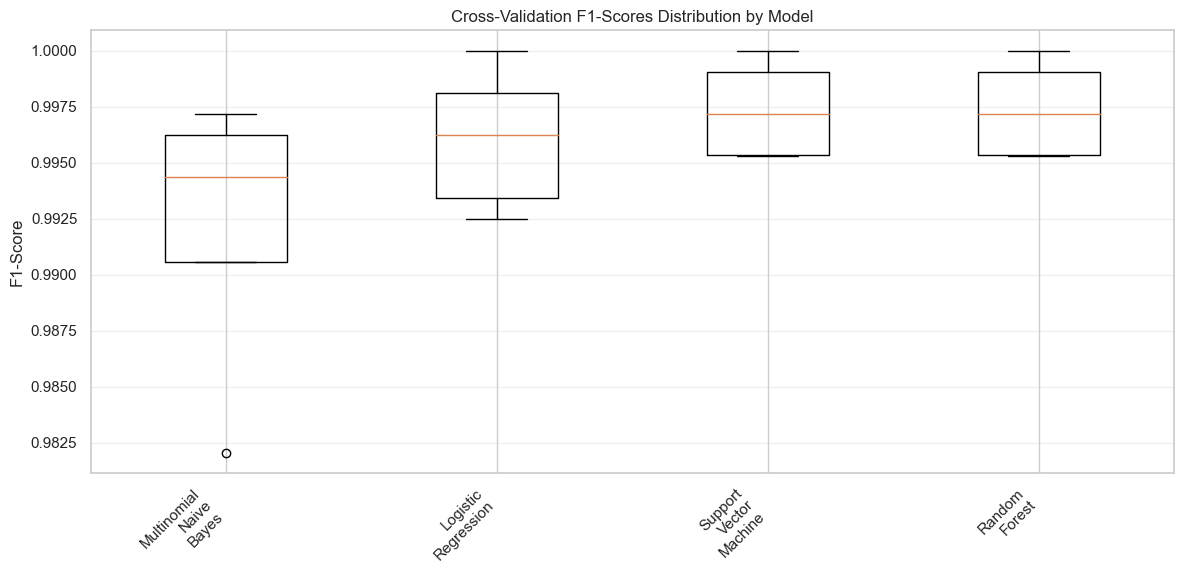


Top 3 models selected for hyperparameter tuning:
1. Support Vector Machine: 0.9974
2. Random Forest: 0.9974
3. Logistic Regression: 0.9961


In [172]:
# Initialize stratified K-fold cross-validation
k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Combine training and validation sets for cross-validation
X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

# Transform combined data using TF-IDF
X_train_val_tfidf = tfidf_vectorizer.fit_transform(X_train_val)

# Store cross-validation results
cv_results = {}

print("Performing K-Fold Cross-Validation...")
print("="*60)

for model_name, model in candidate_models.items():
    print(f"\nEvaluating {model_name}...")
    
    # Perform cross-validation
    cv_scores = cross_val_score(model, X_train_val_tfidf, y_train_val, 
                               cv=skf, scoring='f1_weighted', n_jobs=-1)
    
    # Store results
    cv_results[model_name] = {
        'scores': cv_scores,
        'mean': cv_scores.mean(),
        'std': cv_scores.std(),
        'min': cv_scores.min(),
        'max': cv_scores.max()
    }
    
    print(f"F1-Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    print(f"Individual fold scores: {cv_scores}")

# Create summary table
cv_summary = pd.DataFrame({
    'Model': list(cv_results.keys()),
    'Mean_F1': [results['mean'] for results in cv_results.values()],
    'Std_F1': [results['std'] for results in cv_results.values()],
    'Min_F1': [results['min'] for results in cv_results.values()],
    'Max_F1': [results['max'] for results in cv_results.values()]
}).round(4)

# Sort by mean F1-score
cv_summary = cv_summary.sort_values('Mean_F1', ascending=False)

print(f"\n{k_folds}-Fold Cross-Validation Results Summary:")
print("="*60)
print(cv_summary.to_string(index=False))

# Visualize cross-validation results
plt.figure(figsize=(12, 6))
models = list(cv_results.keys())
scores = [cv_results[model]['scores'] for model in models]

plt.boxplot(scores, labels=[model.replace(' ', '\n') for model in models])
plt.title('Cross-Validation F1-Scores Distribution by Model')
plt.ylabel('F1-Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Select top performing models for hyperparameter tuning
top_models = cv_summary.head(3)['Model'].tolist()
print(f"\nTop 3 models selected for hyperparameter tuning:")
for i, model in enumerate(top_models, 1):
    mean_score = cv_results[model]['mean']
    print(f"{i}. {model}: {mean_score:.4f}")

### 5.2 Hyperparameter Tuning

Optimize the hyperparameters of the top-performing models to achieve better performance.

#### 5.2.1 Optimize Model Settings: Define Hyperparameter Grids

Define hyperparameter grids for the top-performing models based on cross-validation results.

In [173]:
# Define hyperparameter grids for top models
hyperparameter_grids = {
    'Multinomial Naive Bayes': {
        'alpha': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0],
        'fit_prior': [True, False]
    },
    'Logistic Regression': {
        'C': [0.01, 0.1, 1.0, 10.0, 100.0],
        'solver': ['liblinear', 'lbfgs'],
        'penalty': ['l1', 'l2'],
        'max_iter': [1000, 2000]
    },
    'Support Vector Machine': {
        'C': [0.01, 0.1, 1.0, 10.0, 100.0],
        'loss': ['hinge', 'squared_hinge'],
        'max_iter': [5000, 10000]
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
}

# Filter grids for only top performing models
selected_grids = {model: hyperparameter_grids[model] for model in top_models 
                 if model in hyperparameter_grids}

print("Hyperparameter grids defined for top models:")
for model_name, grid in selected_grids.items():
    print(f"\n{model_name}:")
    for param, values in grid.items():
        print(f"  {param}: {values}")

Hyperparameter grids defined for top models:

Support Vector Machine:
  C: [0.01, 0.1, 1.0, 10.0, 100.0]
  loss: ['hinge', 'squared_hinge']
  max_iter: [5000, 10000]

Random Forest:
  n_estimators: [50, 100, 200]
  max_depth: [10, 20, None]
  min_samples_split: [2, 5, 10]
  min_samples_leaf: [1, 2, 4]

Logistic Regression:
  C: [0.01, 0.1, 1.0, 10.0, 100.0]
  solver: ['liblinear', 'lbfgs']
  penalty: ['l1', 'l2']
  max_iter: [1000, 2000]


#### 5.2.2 Grid Search: Systematically Explore Hyperparameter Combinations

Use GridSearchCV to systematically explore different combinations of hyperparameter values.

In [174]:
# Perform grid search for each top model
best_models = {}
grid_search_results = {}

print("Performing Grid Search for Hyperparameter Optimization...")
print("="*70)

for model_name in top_models:
    if model_name in selected_grids:
        print(f"\nOptimizing {model_name}...")
        
        # Get base model
        base_model = candidate_models[model_name]
        param_grid = selected_grids[model_name]
        
        # Handle special case for Logistic Regression penalty-solver compatibility
        if model_name == 'Logistic Regression':
            # Create separate grids for different solver-penalty combinations
            grid_results = []
            
            # L1 penalty only works with liblinear and saga
            l1_grid = {
                'C': param_grid['C'],
                'solver': ['liblinear'],
                'penalty': ['l1'],
                'max_iter': param_grid['max_iter']
            }
            
            # L2 penalty works with both solvers
            l2_grid = {
                'C': param_grid['C'],
                'solver': ['liblinear', 'lbfgs'],
                'penalty': ['l2'],
                'max_iter': param_grid['max_iter']
            }
            
            # Search L1 grid
            grid_search_l1 = GridSearchCV(
                base_model, l1_grid, cv=3, scoring='f1_weighted', 
                n_jobs=-1, verbose=1
            )
            grid_search_l1.fit(X_train_val_tfidf, y_train_val)
            
            # Search L2 grid  
            grid_search_l2 = GridSearchCV(
                base_model, l2_grid, cv=3, scoring='f1_weighted', 
                n_jobs=-1, verbose=1
            )
            grid_search_l2.fit(X_train_val_tfidf, y_train_val)
            
            # Select best between L1 and L2
            if grid_search_l1.best_score_ > grid_search_l2.best_score_:
                grid_search = grid_search_l1
            else:
                grid_search = grid_search_l2
        else:
            # Standard grid search for other models
            grid_search = GridSearchCV(
                base_model, param_grid, cv=3, scoring='f1_weighted', 
                n_jobs=-1, verbose=1
            )
            grid_search.fit(X_train_val_tfidf, y_train_val)
        
        # Store results
        best_models[model_name] = grid_search.best_estimator_
        grid_search_results[model_name] = {
            'best_score': grid_search.best_score_,
            'best_params': grid_search.best_params_,
            'cv_results': grid_search.cv_results_
        }
        
        print(f"Best F1-Score: {grid_search.best_score_:.4f}")
        print(f"Best Parameters: {grid_search.best_params_}")

# Summary of hyperparameter tuning results
print(f"\nHyperparameter Tuning Results Summary:")
print("="*50)

tuning_summary = pd.DataFrame({
    'Model': list(grid_search_results.keys()),
    'Best_F1_Score': [results['best_score'] for results in grid_search_results.values()],
    'Improvement': [
        grid_search_results[model]['best_score'] - cv_results[model]['mean'] 
        for model in grid_search_results.keys()
    ]
}).round(4)

tuning_summary = tuning_summary.sort_values('Best_F1_Score', ascending=False)
print(tuning_summary.to_string(index=False))

# Select the best model overall
best_model_name = tuning_summary.iloc[0]['Model']
best_model = best_models[best_model_name]
best_score = tuning_summary.iloc[0]['Best_F1_Score']

print(f"\n SELECTED BEST MODEL: {best_model_name}")
print(f"   Cross-validation F1-Score: {best_score:.4f}")
print(f"   Optimized Parameters: {grid_search_results[best_model_name]['best_params']}")

Performing Grid Search for Hyperparameter Optimization...

Optimizing Support Vector Machine...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best F1-Score: 0.9955
Best Parameters: {'C': 10.0, 'loss': 'hinge', 'max_iter': 5000}

Optimizing Random Forest...
Fitting 3 folds for each of 81 candidates, totalling 243 fits
Best F1-Score: 0.9955
Best Parameters: {'C': 10.0, 'loss': 'hinge', 'max_iter': 5000}

Optimizing Random Forest...
Fitting 3 folds for each of 81 candidates, totalling 243 fits
Best F1-Score: 0.9955
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}

Optimizing Logistic Regression...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best F1-Score: 0.9955
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}

Optimizing Logistic Regression...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Fitting 3 folds for each of 20 candidates, to

### 5.2.3 Cross-Validation within Tuning: Validate Hyperparameter Selection

The GridSearchCV already incorporates cross-validation. Let's verify the stability of our best model with additional validation.

Additional Cross-Validation for Best Model: Support Vector Machine
10-Fold CV F1-Scores: [1.         1.         0.99812159 0.99624648 1.         0.99812159
 0.99437552 0.99624193 0.9962406  0.99434796]
Mean: 0.9974
Standard Deviation: 0.0021
95% Confidence Interval: [0.9933, 1.0015]
10-Fold CV F1-Scores: [1.         1.         0.99812159 0.99624648 1.         0.99812159
 0.99437552 0.99624193 0.9962406  0.99434796]
Mean: 0.9974
Standard Deviation: 0.0021
95% Confidence Interval: [0.9933, 1.0015]


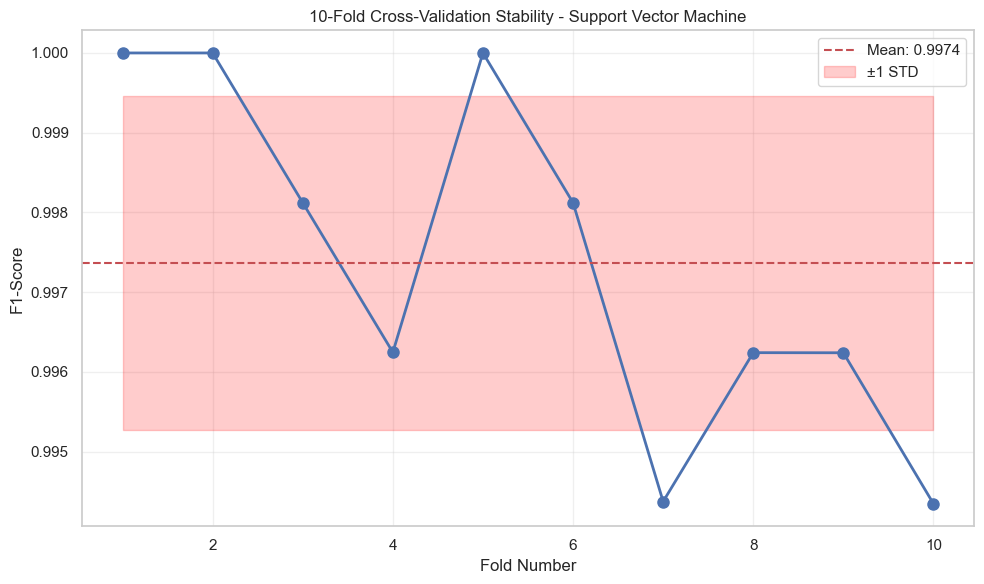


Model Stability Assessment: Stable
Coefficient of Variation: 0.21%


In [175]:
# Perform additional cross-validation on the best model to ensure stability
print(f"Additional Cross-Validation for Best Model: {best_model_name}")
print("="*60)

# Use 10-fold CV for more robust validation
extended_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
extended_scores = cross_val_score(best_model, X_train_val_tfidf, y_train_val, 
                                 cv=extended_cv, scoring='f1_weighted', n_jobs=-1)

print(f"10-Fold CV F1-Scores: {extended_scores}")
print(f"Mean: {extended_scores.mean():.4f}")
print(f"Standard Deviation: {extended_scores.std():.4f}")
print(f"95% Confidence Interval: [{extended_scores.mean() - 1.96*extended_scores.std():.4f}, "
      f"{extended_scores.mean() + 1.96*extended_scores.std():.4f}]")

# Visualize the stability
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), extended_scores, 'bo-', linewidth=2, markersize=8)
plt.axhline(y=extended_scores.mean(), color='r', linestyle='--', 
           label=f'Mean: {extended_scores.mean():.4f}')
plt.fill_between(range(1, 11), 
                extended_scores.mean() - extended_scores.std(),
                extended_scores.mean() + extended_scores.std(),
                alpha=0.2, color='red', label='±1 STD')
plt.title(f'10-Fold Cross-Validation Stability - {best_model_name}')
plt.xlabel('Fold Number')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Check if model performance is consistent
cv_stability = "Stable" if extended_scores.std() < 0.02 else "Moderate" if extended_scores.std() < 0.05 else "Unstable"
print(f"\nModel Stability Assessment: {cv_stability}")
print(f"Coefficient of Variation: {(extended_scores.std() / extended_scores.mean()) * 100:.2f}%")

### 6. Model Training

Train the selected model with optimized hyperparameters on the complete training dataset.

In [176]:
# Retrain the best model on the full training set with optimized hyperparameters
print(f"Training Selected Model: {best_model_name}")
print("="*50)

# Prepare final training data (combining train and validation sets)
X_final_train = X_train_val_tfidf
y_final_train = y_train_val

# Train the final model
final_model = best_model
final_model.fit(X_final_train, y_final_train)

# Prepare test data
X_test_tfidf_final = tfidf_vectorizer.transform(X_test)

print(f"✓ Model training completed successfully")
print(f"✓ Training data shape: {X_final_train.shape}")
print(f"✓ Test data prepared: {X_test_tfidf_final.shape}")
print(f"✓ Model type: {type(final_model).__name__}")
print(f"✓ Optimized parameters: {grid_search_results[best_model_name]['best_params']}")

# Display model details
if hasattr(final_model, 'feature_log_prob_') and best_model_name == 'Multinomial Naive Bayes':
    print(f"✓ Vocabulary size: {final_model.feature_log_prob_.shape[1]}")
elif hasattr(final_model, 'coef_'):
    print(f"✓ Feature coefficients shape: {final_model.coef_.shape}")

Training Selected Model: Support Vector Machine
✓ Model training completed successfully
✓ Training data shape: (5328, 3235)
✓ Test data prepared: (1333, 3235)
✓ Model type: LinearSVC
✓ Optimized parameters: {'C': 10.0, 'loss': 'hinge', 'max_iter': 5000}
✓ Feature coefficients shape: (25, 3235)
✓ Model training completed successfully
✓ Training data shape: (5328, 3235)
✓ Test data prepared: (1333, 3235)
✓ Model type: LinearSVC
✓ Optimized parameters: {'C': 10.0, 'loss': 'hinge', 'max_iter': 5000}
✓ Feature coefficients shape: (25, 3235)


## 7. Model Evaluation

Comprehensive evaluation of the trained model's performance using multiple metrics and visualization techniques.

### 7.1 Assess Performance: Evaluate Using Multiple Metrics

Calculate accuracy, precision, recall, and F1-score on the test set.

MODEL PERFORMANCE EVALUATION
Selected Model: Support Vector Machine
Test Set Size: 1333 samples
Number of Classes: 25

OVERALL PERFORMANCE METRICS:
------------------------------
Accuracy:  0.9955
Precision: 0.9958
Recall:    0.9955
F1-Score:  0.9955

DETAILED CLASSIFICATION REPORT:
----------------------------------------
                    precision    recall  f1-score   support

              Acne     1.0000    1.0000    1.0000        66
         Back pain     1.0000    1.0000    1.0000        52
     Blurry vision     1.0000    1.0000    1.0000        49
   Body feels weak     1.0000    0.9792    0.9895        48
             Cough     1.0000    1.0000    1.0000        59
          Ear ache     1.0000    1.0000    1.0000        54
    Emotional pain     1.0000    1.0000    1.0000        46
      Feeling cold     1.0000    1.0000    1.0000        53
     Feeling dizzy     1.0000    1.0000    1.0000        57
         Foot ache     1.0000    1.0000    1.0000        44
  Hair falling

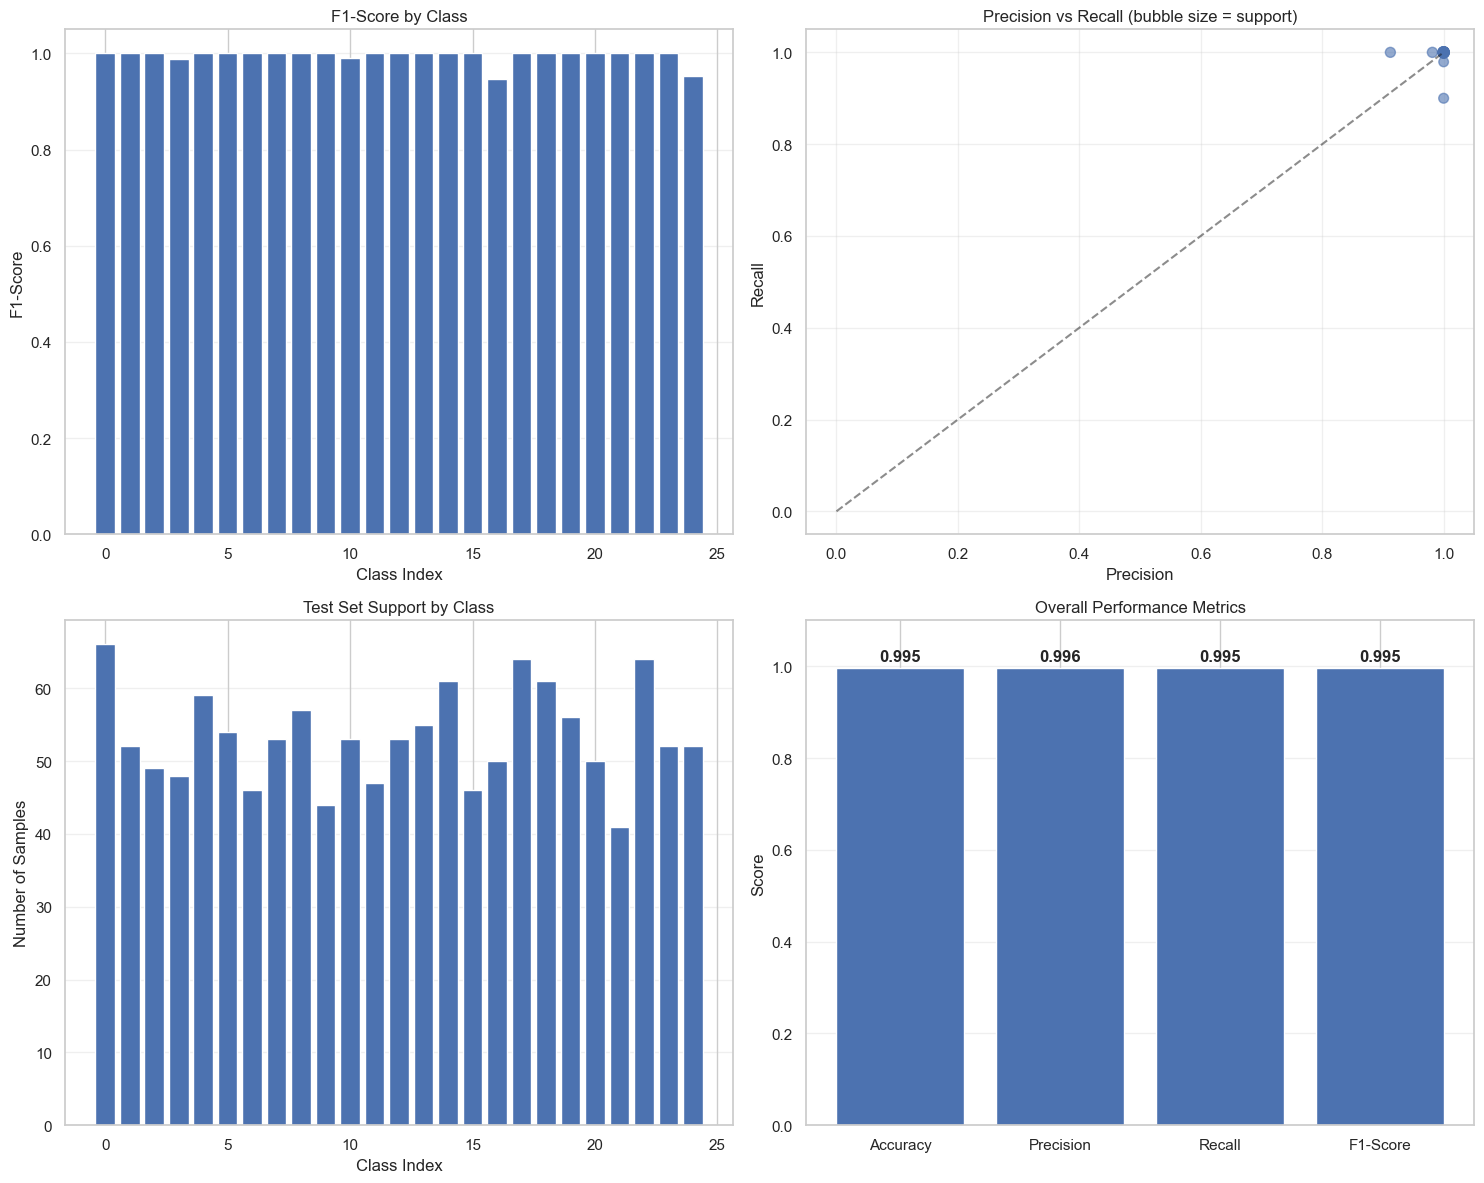

In [177]:
# Make predictions on test set
y_test_pred = final_model.predict(X_test_tfidf_final)

# Calculate primary metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision, test_recall, test_f1, test_support = precision_recall_fscore_support(
    y_test, y_test_pred, average='weighted', zero_division=0
)

# Calculate per-class metrics
precision_per_class, recall_per_class, f1_per_class, support_per_class = precision_recall_fscore_support(
    y_test, y_test_pred, average=None, zero_division=0
)

print(f"MODEL PERFORMANCE EVALUATION")
print("="*50)
print(f"Selected Model: {best_model_name}")
print(f"Test Set Size: {len(y_test)} samples")
print(f"Number of Classes: {len(np.unique(y_test))}")

print(f"\nOVERALL PERFORMANCE METRICS:")
print("-" * 30)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")

# Detailed classification report
print(f"\nDETAILED CLASSIFICATION REPORT:")
print("-" * 40)
class_names = [label_encoder.inverse_transform([i])[0] for i in range(len(label_encoder.classes_))]
print(classification_report(y_test, y_test_pred, target_names=class_names, digits=4))

# Create performance summary DataFrame
performance_summary = pd.DataFrame({
    'Class': class_names,
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1_Score': f1_per_class,
    'Support': support_per_class
}).round(4)

# Add summary statistics
summary_stats = pd.DataFrame({
    'Class': ['MACRO AVG', 'WEIGHTED AVG'],
    'Precision': [precision_per_class.mean(), test_precision],
    'Recall': [recall_per_class.mean(), test_recall],
    'F1_Score': [f1_per_class.mean(), test_f1],
    'Support': [support_per_class.sum(), support_per_class.sum()]
}).round(4)

performance_summary = pd.concat([performance_summary, summary_stats], ignore_index=True)

print(f"\nPERFORMANCE SUMMARY TABLE:")
print("-" * 30)
print(performance_summary.to_string(index=False))

# Visualize performance metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Per-class F1-scores
axes[0, 0].bar(range(len(f1_per_class)), f1_per_class)
axes[0, 0].set_title('F1-Score by Class')
axes[0, 0].set_xlabel('Class Index')
axes[0, 0].set_ylabel('F1-Score')
axes[0, 0].grid(axis='y', alpha=0.3)

# Plot 2: Precision vs Recall scatter
axes[0, 1].scatter(precision_per_class, recall_per_class, s=support_per_class, alpha=0.6)
axes[0, 1].set_xlabel('Precision')
axes[0, 1].set_ylabel('Recall')
axes[0, 1].set_title('Precision vs Recall (bubble size = support)')
axes[0, 1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Support distribution
axes[1, 0].bar(range(len(support_per_class)), support_per_class)
axes[1, 0].set_title('Test Set Support by Class')
axes[1, 0].set_xlabel('Class Index')
axes[1, 0].set_ylabel('Number of Samples')
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 4: Overall metrics comparison
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [test_accuracy, test_precision, test_recall, test_f1]
bars = axes[1, 1].bar(metrics_names, metrics_values)
axes[1, 1].set_title('Overall Performance Metrics')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_ylim(0, 1.1)
axes[1, 1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, value in zip(bars, metrics_values):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                   f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### 7.2 Comprehensive Model Evaluation: All Stages Analysis

Generate confusion matrices, ROC curves, and detailed tabular information for training, validation, and testing stages to provide complete model performance assessment.

PREPARING DATA FOR COMPREHENSIVE EVALUATION...
Training set: 4262 samples
Validation set: 1066 samples
Testing set: 1333 samples

COMPREHENSIVE EVALUATION - TRAINING STAGE
Dataset Size: 4262 samples
Number of Classes: 25

OVERALL METRICS:
Accuracy:  0.9979
Precision: 0.9979
Recall:    0.9979
F1-Score:  0.9979

DETAILED PERFORMANCE TABLE:
--------------------------------------------------------------------------------
             Class  Precision  Recall  F1_Score  Support  Accuracy
              Acne     1.0000  1.0000    1.0000      209    1.0000
         Back pain     0.9940  1.0000    0.9970      166    1.0000
     Blurry vision     1.0000  1.0000    1.0000      158    1.0000
   Body feels weak     1.0000  1.0000    1.0000      154    1.0000
             Cough     1.0000  1.0000    1.0000      187    1.0000
          Ear ache     1.0000  1.0000    1.0000      173    1.0000
    Emotional pain     1.0000  1.0000    1.0000      148    1.0000
      Feeling cold     1.0000  1.0000    1.

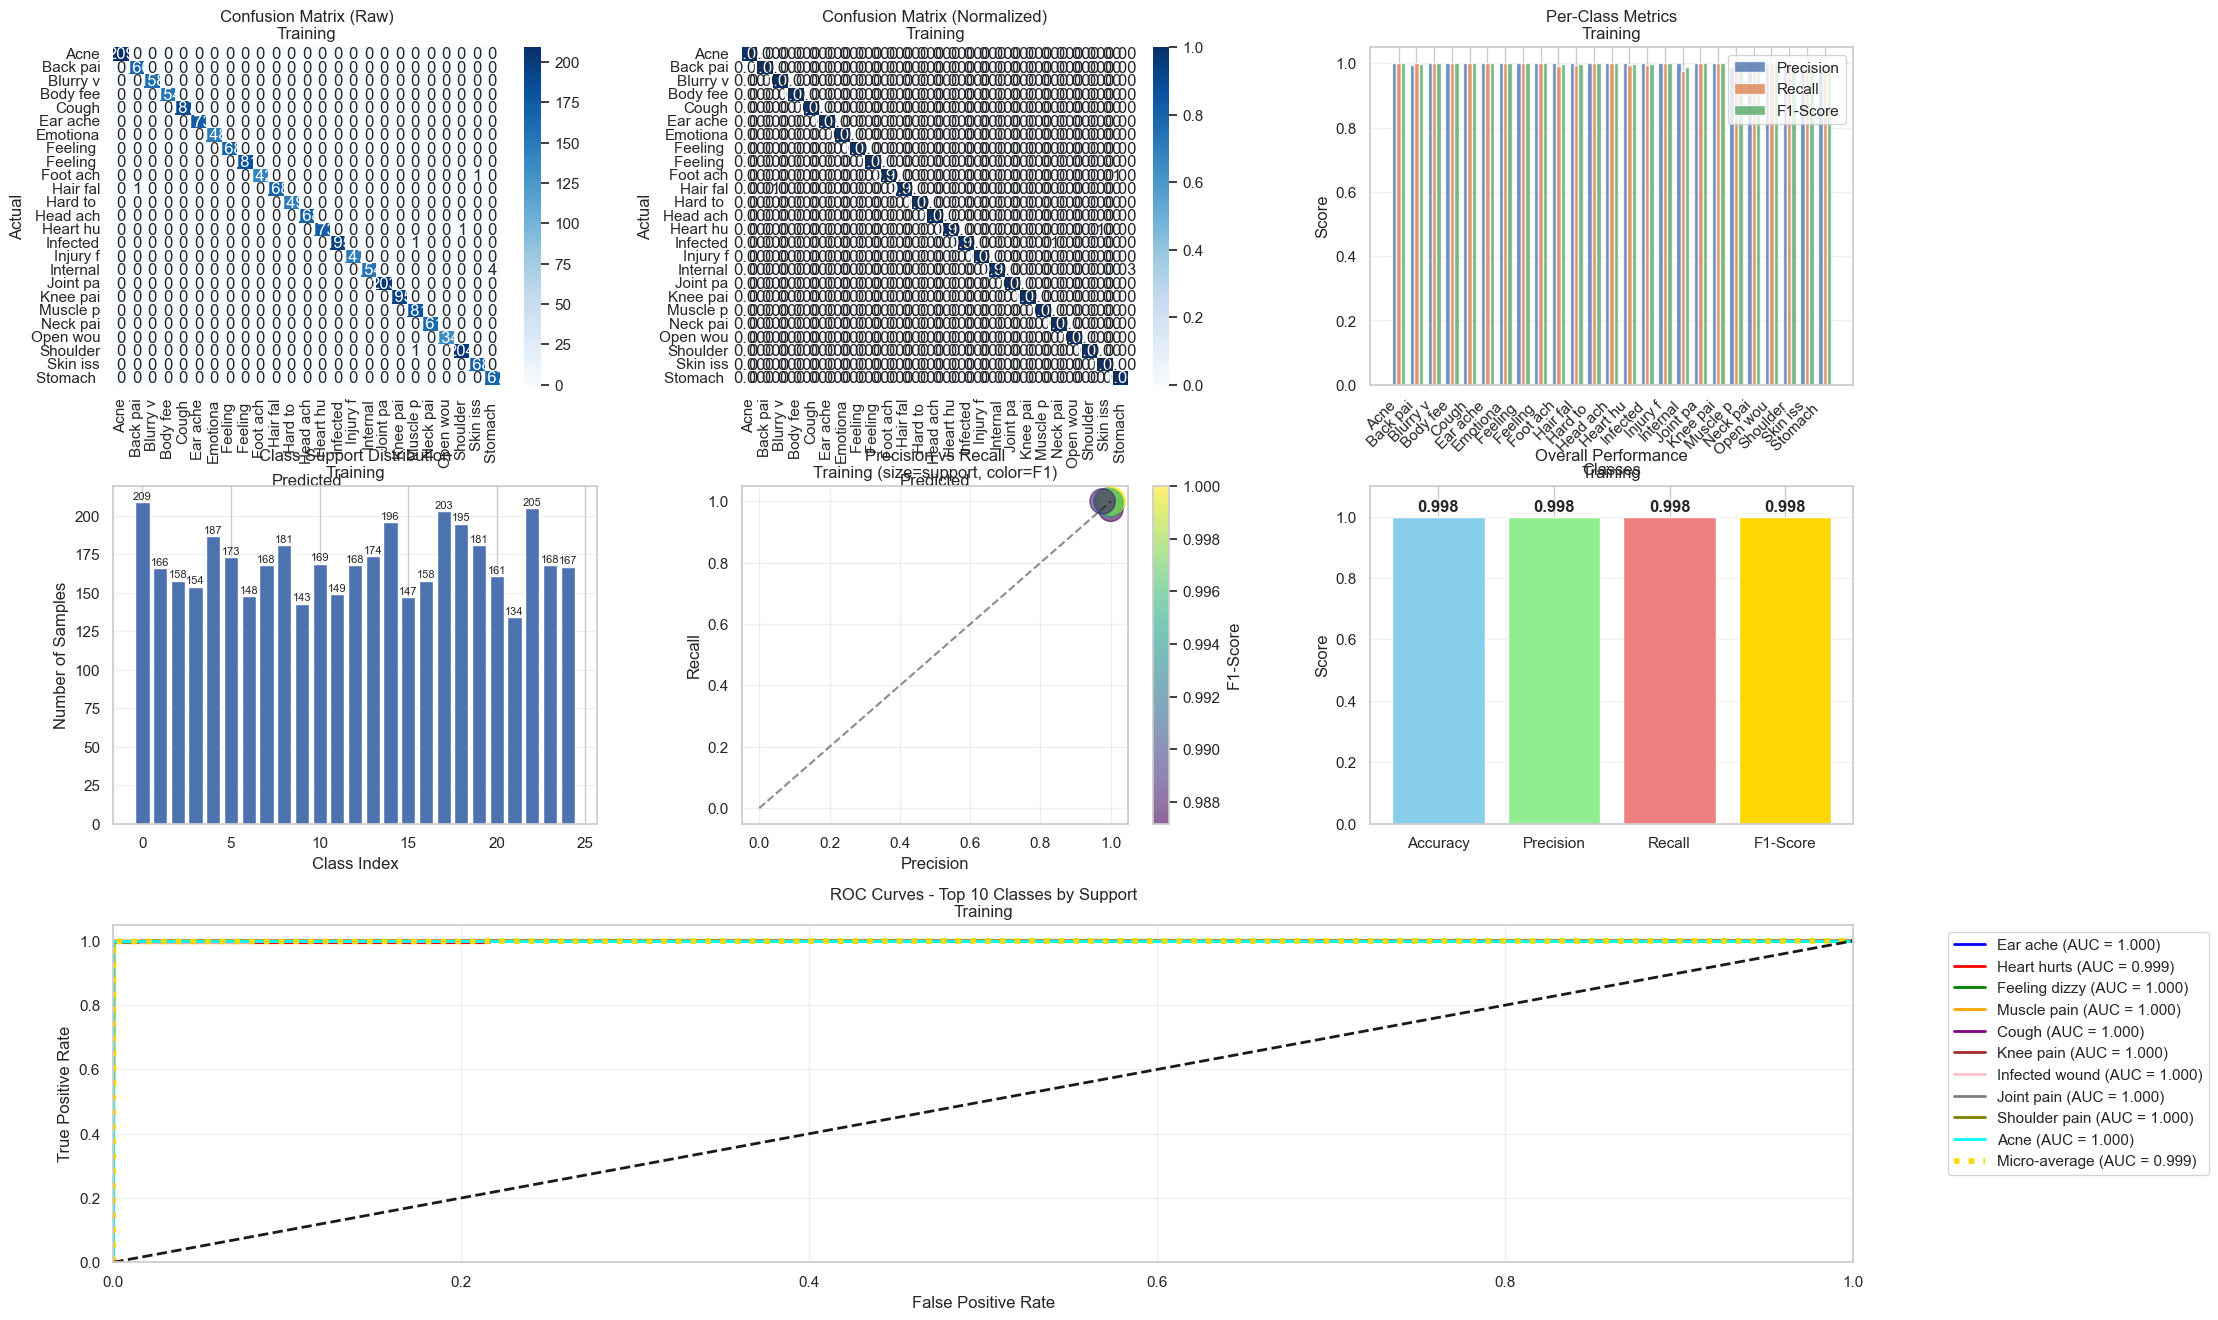


COMPREHENSIVE EVALUATION - VALIDATION STAGE
Dataset Size: 1066 samples
Number of Classes: 25

OVERALL METRICS:
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000

DETAILED PERFORMANCE TABLE:
--------------------------------------------------------------------------------
             Class  Precision  Recall  F1_Score  Support  Accuracy
              Acne        1.0     1.0       1.0       53       1.0
         Back pain        1.0     1.0       1.0       41       1.0
     Blurry vision        1.0     1.0       1.0       39       1.0
   Body feels weak        1.0     1.0       1.0       39       1.0
             Cough        1.0     1.0       1.0       47       1.0
          Ear ache        1.0     1.0       1.0       43       1.0
    Emotional pain        1.0     1.0       1.0       37       1.0
      Feeling cold        1.0     1.0       1.0       42       1.0
     Feeling dizzy        1.0     1.0       1.0       45       1.0
         Foot ache        1.0     1.

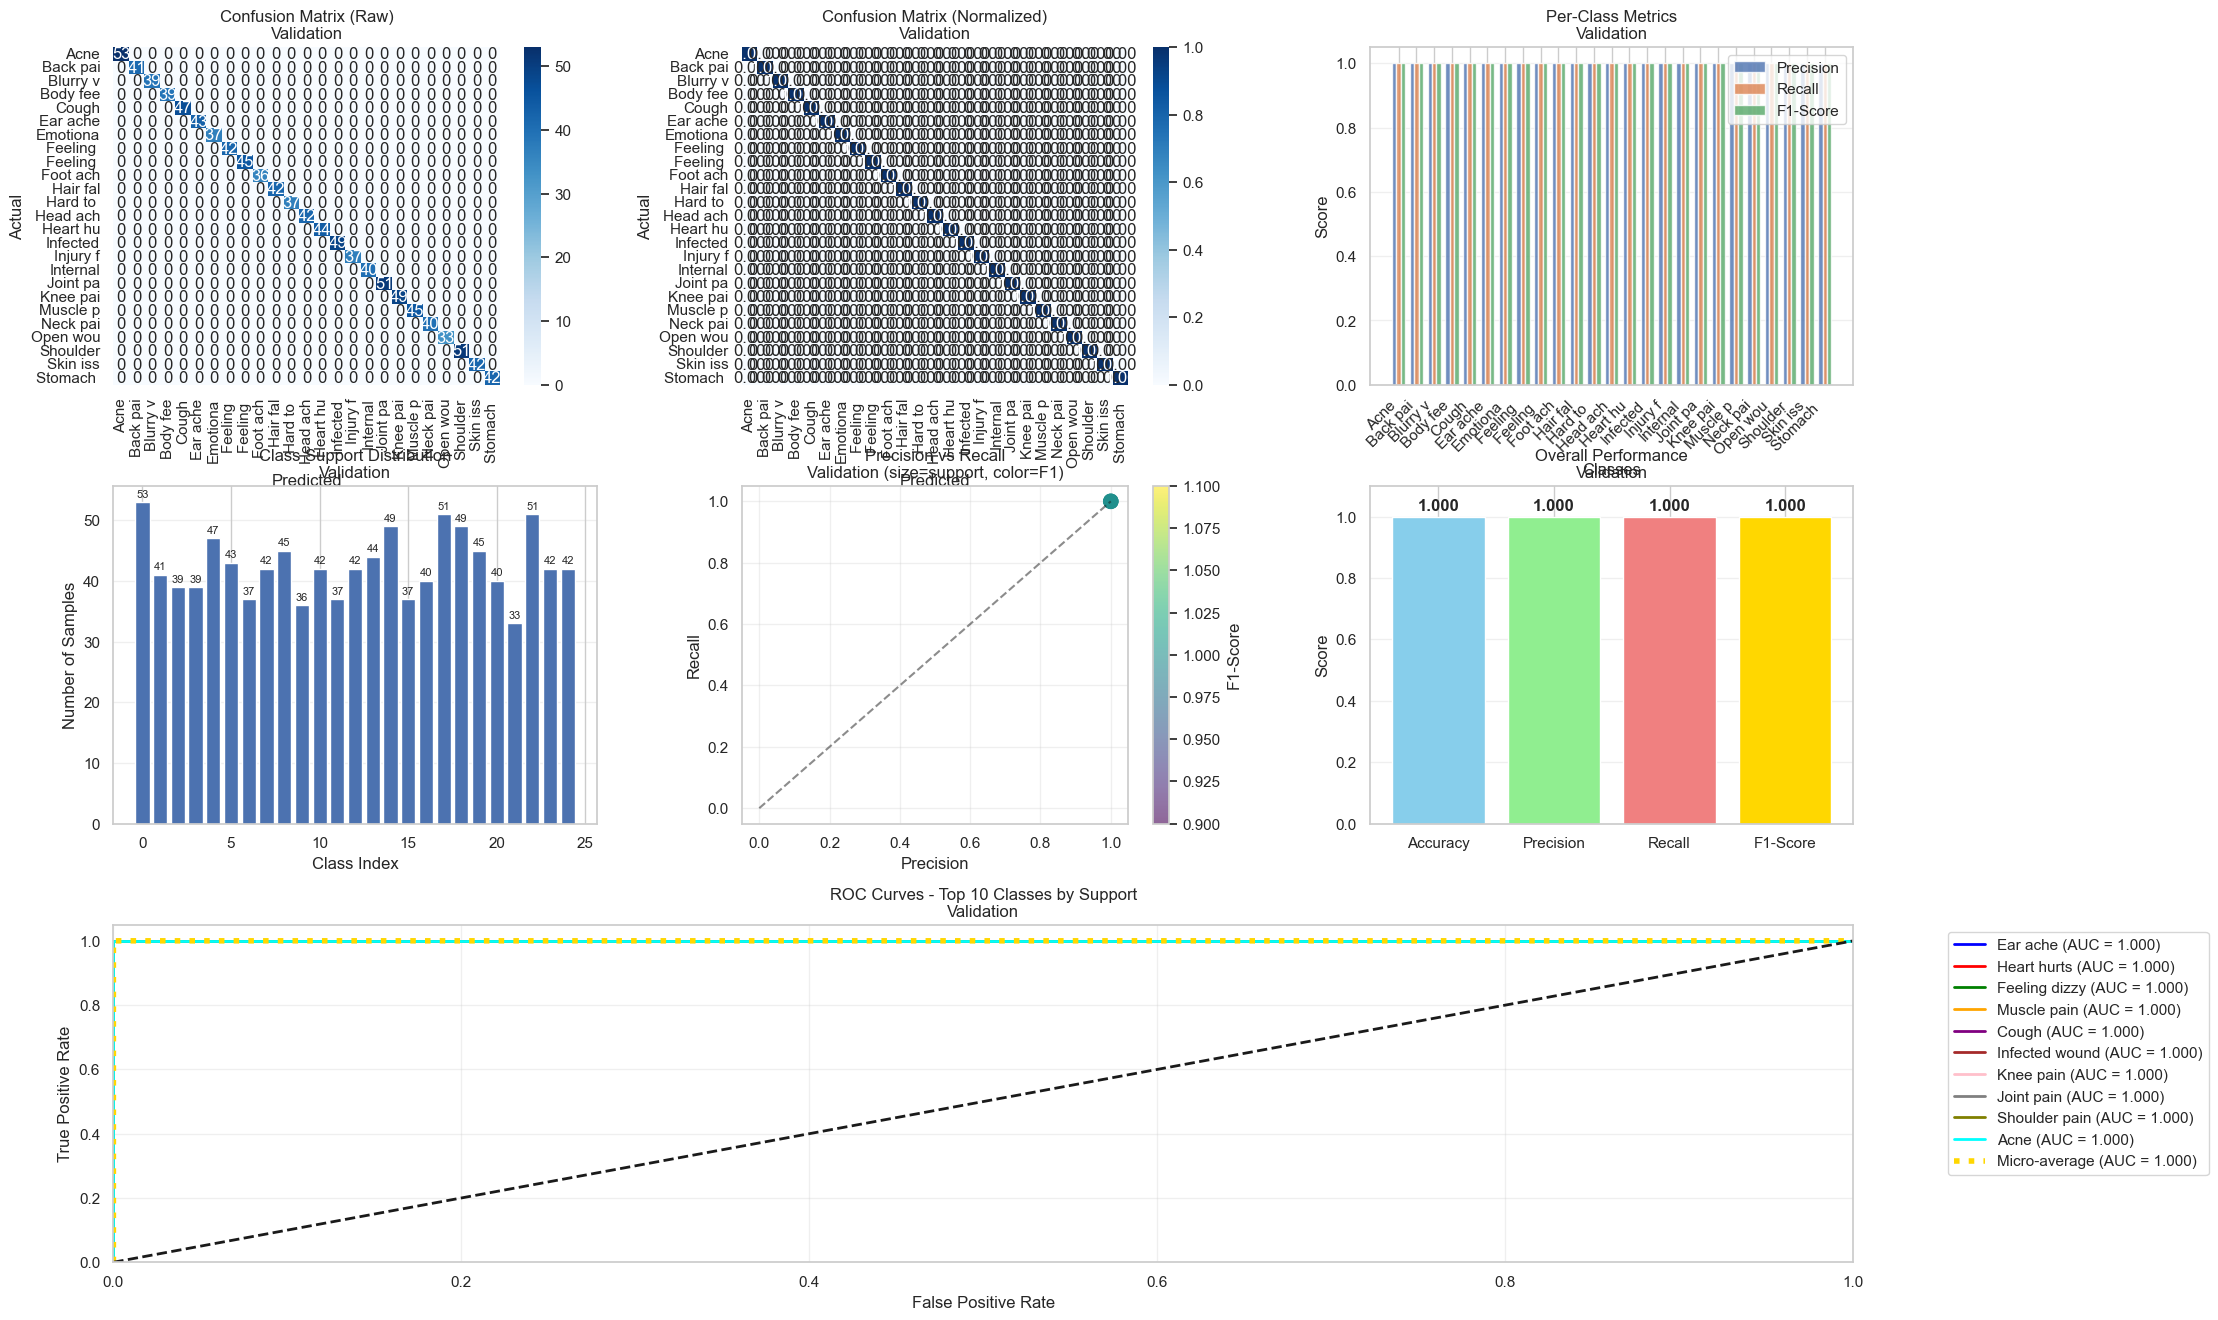


COMPREHENSIVE EVALUATION - TESTING STAGE
Dataset Size: 1333 samples
Number of Classes: 25

OVERALL METRICS:
Accuracy:  0.9955
Precision: 0.9958
Recall:    0.9955
F1-Score:  0.9955

DETAILED PERFORMANCE TABLE:
--------------------------------------------------------------------------------
             Class  Precision  Recall  F1_Score  Support  Accuracy
              Acne     1.0000  1.0000    1.0000       66    1.0000
         Back pain     1.0000  1.0000    1.0000       52    1.0000
     Blurry vision     1.0000  1.0000    1.0000       49    1.0000
   Body feels weak     1.0000  0.9792    0.9895       48    0.9792
             Cough     1.0000  1.0000    1.0000       59    1.0000
          Ear ache     1.0000  1.0000    1.0000       54    1.0000
    Emotional pain     1.0000  1.0000    1.0000       46    1.0000
      Feeling cold     1.0000  1.0000    1.0000       53    1.0000
     Feeling dizzy     1.0000  1.0000    1.0000       57    1.0000
         Foot ache     1.0000  1.0000  

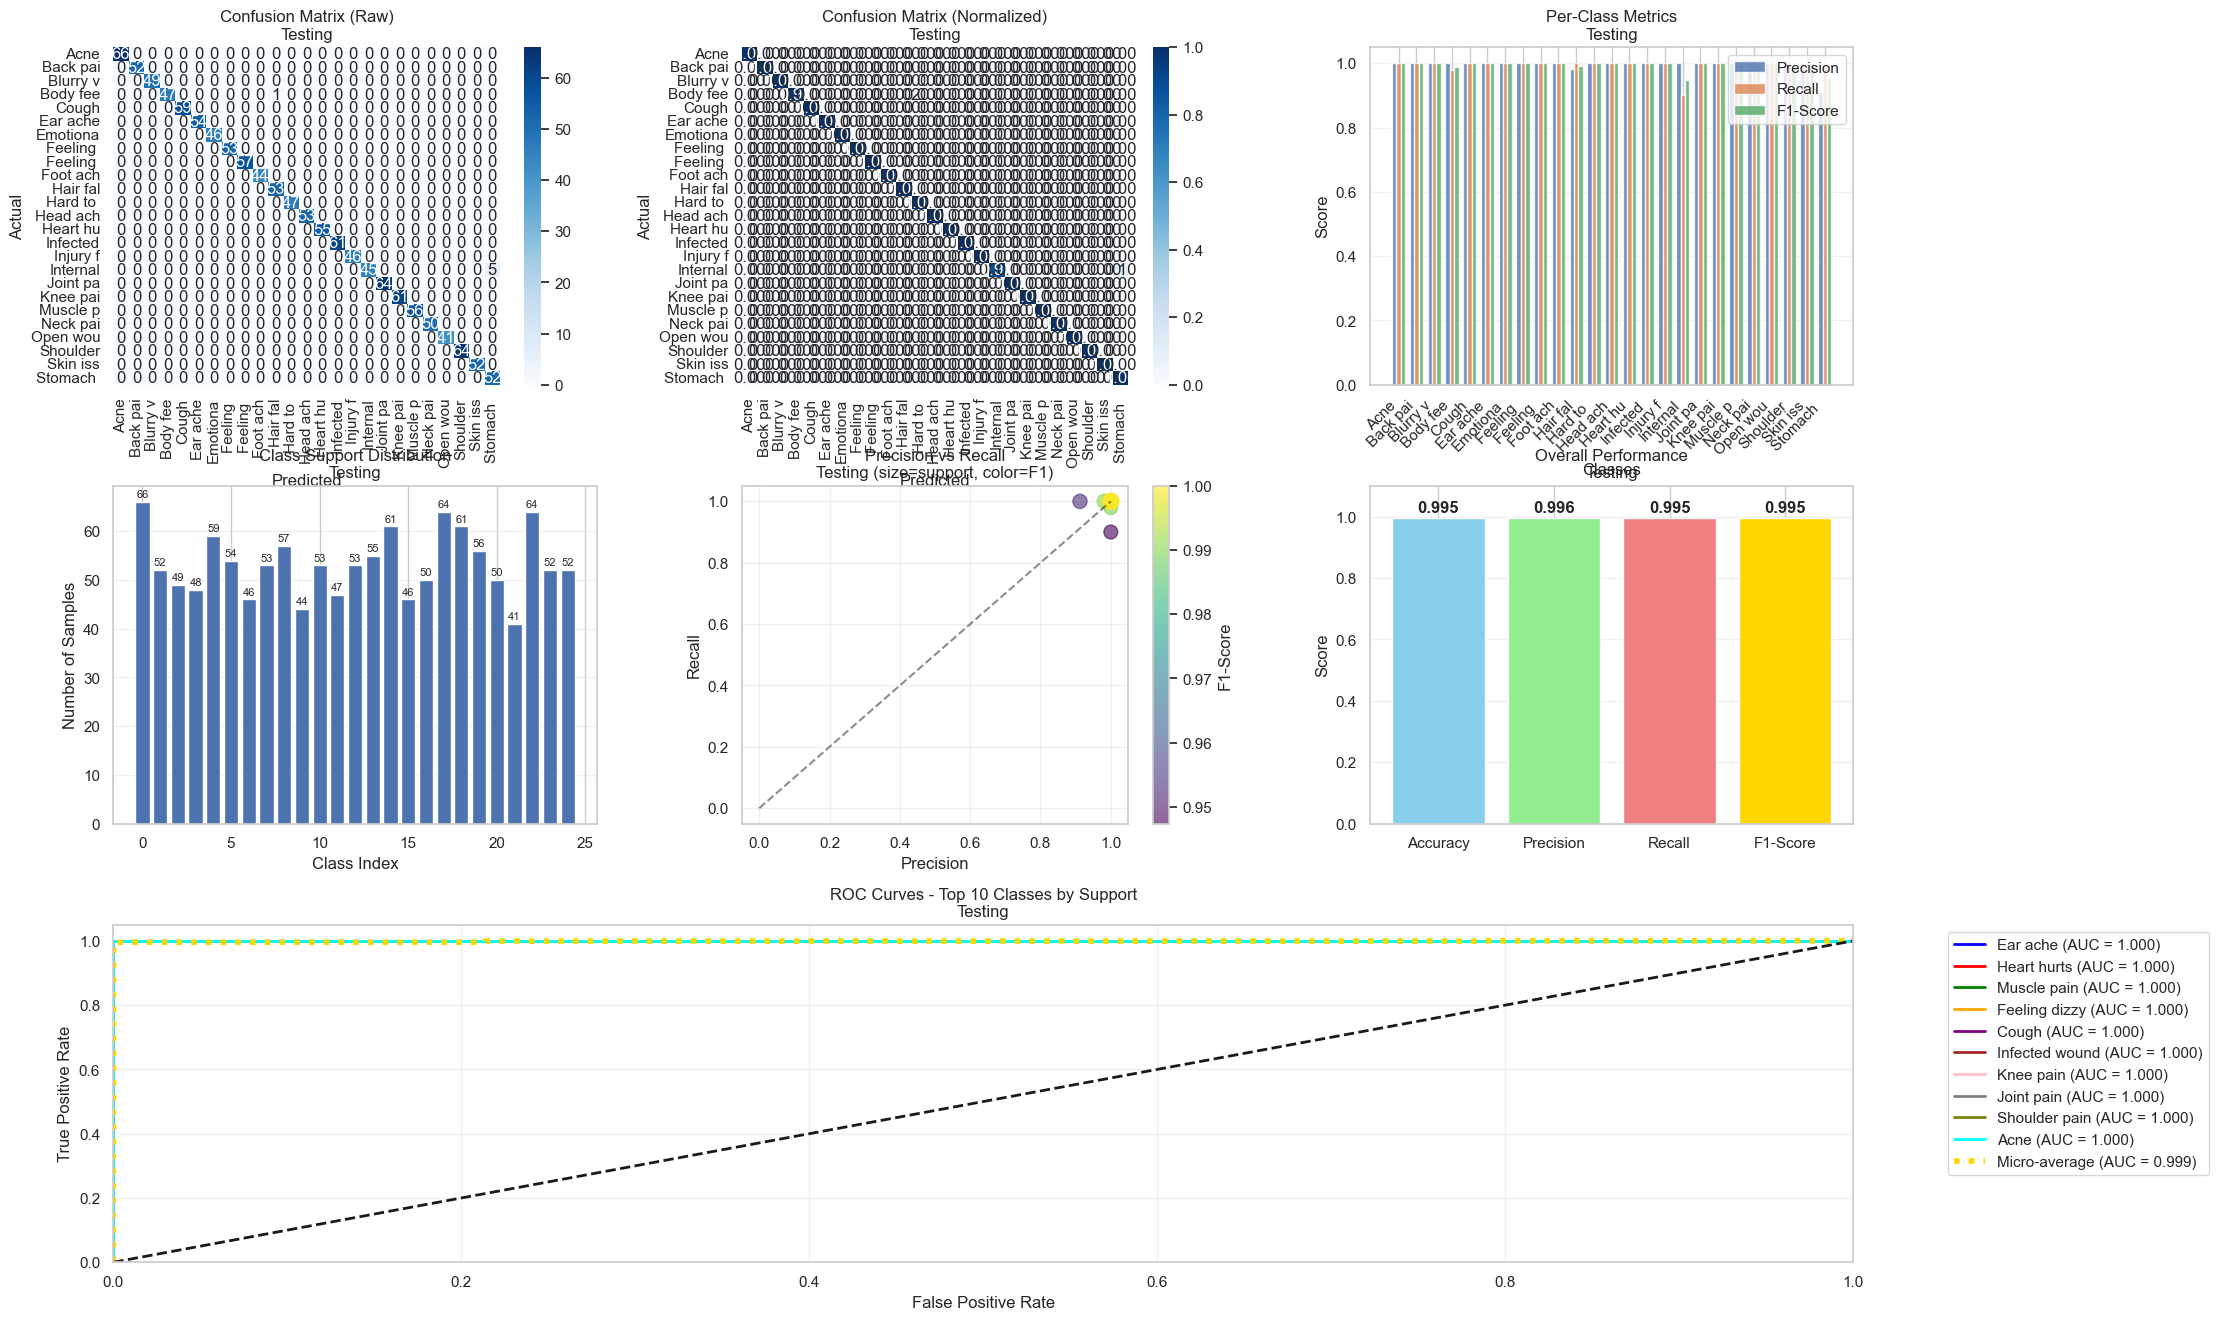

In [178]:
# Import additional libraries needed for comprehensive evaluation
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from itertools import cycle
from scipy import interp

# Function to evaluate model performance on any dataset
def evaluate_model_comprehensive(model, X_data, y_true, stage_name, class_names, vectorizer=None):
    """
    Comprehensive model evaluation including confusion matrix, classification metrics, and ROC analysis
    """
    print(f"\n{'='*60}")
    print(f"COMPREHENSIVE EVALUATION - {stage_name.upper()} STAGE")
    print(f"{'='*60}")
    
    # Transform data if vectorizer provided
    if vectorizer is not None:
        X_transformed = vectorizer.transform(X_data)
    else:
        X_transformed = X_data
    
    # Make predictions
    y_pred = model.predict(X_transformed)
    
    # Get prediction probabilities (if available)
    try:
        if hasattr(model, 'predict_proba'):
            y_proba = model.predict_proba(X_transformed)
        elif hasattr(model, 'decision_function'):
            y_scores = model.decision_function(X_transformed)
            # Convert decision function scores to probabilities for multi-class
            from sklearn.preprocessing import MinMaxScaler
            scaler = MinMaxScaler()
            y_proba = scaler.fit_transform(y_scores)
        else:
            y_proba = None
    except:
        y_proba = None
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )
    
    # Per-class metrics
    precision_per_class, recall_per_class, f1_per_class, support_per_class = precision_recall_fscore_support(
        y_true, y_pred, average=None, zero_division=0
    )
    
    # Generate confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    cm_normalized = confusion_matrix(y_true, y_pred, normalize='true')
    
    # Print summary metrics
    print(f"Dataset Size: {len(y_true)} samples")
    print(f"Number of Classes: {len(np.unique(y_true))}")
    print(f"\nOVERALL METRICS:")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    
    # Create detailed performance table
    performance_df = pd.DataFrame({
        'Class': [class_names[i] for i in range(len(class_names))],
        'Precision': precision_per_class,
        'Recall': recall_per_class,
        'F1_Score': f1_per_class,
        'Support': support_per_class,
        'Accuracy': cm.diagonal() / cm.sum(axis=1)
    }).round(4)
    
    # Add macro and weighted averages
    macro_avg = pd.DataFrame({
        'Class': ['MACRO AVG'],
        'Precision': [precision_per_class.mean()],
        'Recall': [recall_per_class.mean()],
        'F1_Score': [f1_per_class.mean()],
        'Support': [support_per_class.sum()],
        'Accuracy': [cm.diagonal().sum() / cm.sum()]
    }).round(4)
    
    weighted_avg = pd.DataFrame({
        'Class': ['WEIGHTED AVG'],
        'Precision': [precision],
        'Recall': [recall],
        'F1_Score': [f1],
        'Support': [support_per_class.sum()],
        'Accuracy': [accuracy]
    }).round(4)
    
    performance_df = pd.concat([performance_df, macro_avg, weighted_avg], ignore_index=True)
    
    print(f"\nDETAILED PERFORMANCE TABLE:")
    print("-" * 80)
    print(performance_df.to_string(index=False))
    
    # Visualizations
    fig = plt.figure(figsize=(20, 15))
    
    # Create a 3x3 grid for comprehensive visualization
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # 1. Raw Confusion Matrix
    ax1 = fig.add_subplot(gs[0, 0])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
               xticklabels=[name[:8] for name in class_names], 
               yticklabels=[name[:8] for name in class_names])
    ax1.set_title(f'Confusion Matrix (Raw)\n{stage_name}')
    ax1.set_xlabel('Predicted')
    ax1.set_ylabel('Actual')
    
    # 2. Normalized Confusion Matrix
    ax2 = fig.add_subplot(gs[0, 1])
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', ax=ax2,
               xticklabels=[name[:8] for name in class_names], 
               yticklabels=[name[:8] for name in class_names])
    ax2.set_title(f'Confusion Matrix (Normalized)\n{stage_name}')
    ax2.set_xlabel('Predicted')
    ax2.set_ylabel('Actual')
    
    # 3. Per-Class Metrics Comparison
    ax3 = fig.add_subplot(gs[0, 2])
    x_pos = np.arange(len(class_names))
    width = 0.25
    ax3.bar(x_pos - width, precision_per_class, width, label='Precision', alpha=0.8)
    ax3.bar(x_pos, recall_per_class, width, label='Recall', alpha=0.8)
    ax3.bar(x_pos + width, f1_per_class, width, label='F1-Score', alpha=0.8)
    ax3.set_title(f'Per-Class Metrics\n{stage_name}')
    ax3.set_xlabel('Classes')
    ax3.set_ylabel('Score')
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels([name[:8] for name in class_names], rotation=45, ha='right')
    ax3.legend()
    ax3.grid(axis='y', alpha=0.3)
    
    # 4. Support Distribution
    ax4 = fig.add_subplot(gs[1, 0])
    bars = ax4.bar(range(len(support_per_class)), support_per_class)
    ax4.set_title(f'Class Support Distribution\n{stage_name}')
    ax4.set_xlabel('Class Index')
    ax4.set_ylabel('Number of Samples')
    ax4.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, (bar, value) in enumerate(zip(bars, support_per_class)):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                str(int(value)), ha='center', va='bottom', fontsize=8)
    
    # 5. Precision vs Recall Scatter
    ax5 = fig.add_subplot(gs[1, 1])
    scatter = ax5.scatter(precision_per_class, recall_per_class, 
                         s=support_per_class*2, alpha=0.6, c=f1_per_class, 
                         cmap='viridis')
    ax5.set_xlabel('Precision')
    ax5.set_ylabel('Recall')
    ax5.set_title(f'Precision vs Recall\n{stage_name} (size=support, color=F1)')
    ax5.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax5.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax5, label='F1-Score')
    
    # 6. Overall Metrics Bar Chart
    ax6 = fig.add_subplot(gs[1, 2])
    metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    metrics_values = [accuracy, precision, recall, f1]
    bars = ax6.bar(metrics_names, metrics_values, color=['skyblue', 'lightgreen', 'lightcoral', 'gold'])
    ax6.set_title(f'Overall Performance\n{stage_name}')
    ax6.set_ylabel('Score')
    ax6.set_ylim(0, 1.1)
    ax6.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for bar, value in zip(bars, metrics_values):
        ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # 7-9. ROC Curves (if probabilities available)
    if y_proba is not None and len(np.unique(y_true)) > 2:
        # Multi-class ROC curves
        n_classes = len(class_names)
        
        # Binarize the output
        y_true_bin = label_binarize(y_true, classes=range(n_classes))
        
        # Compute ROC curve and ROC area for each class
        fpr = dict()
        tpr = dict()
        roc_auc = dict()
        
        for i in range(n_classes):
            if len(np.unique(y_true_bin[:, i])) > 1:  # Check if class exists in this dataset
                fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
                roc_auc[i] = auc(fpr[i], tpr[i])
        
        # Compute micro-average ROC curve and ROC area
        if len(fpr) > 0:
            fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_proba.ravel())
            roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
        
        # Plot ROC curves for top classes by support
        ax7 = fig.add_subplot(gs[2, :])
        
        # Select top 10 classes by support for cleaner visualization
        top_classes_idx = np.argsort(support_per_class)[-10:]
        
        colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan'])
        
        for i, color in zip(top_classes_idx, colors):
            if i in fpr:
                ax7.plot(fpr[i], tpr[i], color=color, lw=2,
                        label=f'{class_names[i][:15]} (AUC = {roc_auc[i]:.3f})')
        
        if "micro" in fpr:
            ax7.plot(fpr["micro"], tpr["micro"], color='gold', linestyle=':', linewidth=4,
                    label=f'Micro-average (AUC = {roc_auc["micro"]:.3f})')
        
        ax7.plot([0, 1], [0, 1], 'k--', lw=2)
        ax7.set_xlim([0.0, 1.0])
        ax7.set_ylim([0.0, 1.05])
        ax7.set_xlabel('False Positive Rate')
        ax7.set_ylabel('True Positive Rate')
        ax7.set_title(f'ROC Curves - Top 10 Classes by Support\n{stage_name}')
        ax7.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax7.grid(True, alpha=0.3)
        
        # Calculate and display average AUC
        if len(roc_auc) > 0:
            valid_aucs = [auc_val for key, auc_val in roc_auc.items() if key != "micro"]
            avg_auc = np.mean(valid_aucs) if valid_aucs else 0
            print(f"\nROC AUC ANALYSIS:")
            print(f"Average AUC across classes: {avg_auc:.4f}")
            print(f"Micro-average AUC: {roc_auc.get('micro', 'N/A')}")
    
    elif y_proba is not None and len(np.unique(y_true)) == 2:
        # Binary classification ROC
        fpr, tpr, _ = roc_curve(y_true, y_proba[:, 1])
        roc_auc = auc(fpr, tpr)
        
        ax7 = fig.add_subplot(gs[2, :])
        ax7.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
        ax7.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        ax7.set_xlim([0.0, 1.0])
        ax7.set_ylim([0.0, 1.05])
        ax7.set_xlabel('False Positive Rate')
        ax7.set_ylabel('True Positive Rate')
        ax7.set_title(f'ROC Curve\n{stage_name}')
        ax7.legend(loc="lower right")
        ax7.grid(True, alpha=0.3)
        
        print(f"\nROC AUC: {roc_auc:.4f}")
    
    else:
        # No probability predictions available
        ax7 = fig.add_subplot(gs[2, :])
        ax7.text(0.5, 0.5, f'ROC curves not available\n{stage_name}\n(Model does not support probability predictions)', 
                ha='center', va='center', fontsize=14, 
                bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
        ax7.set_xlim([0, 1])
        ax7.set_ylim([0, 1])
        ax7.set_title(f'ROC Analysis\n{stage_name}')
    
    plt.tight_layout()
    plt.show()
    
    # Return results for comparison
    return {
        'stage': stage_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'performance_df': performance_df,
        'confusion_matrix': cm,
        'predictions': y_pred,
        'probabilities': y_proba
    }

# Prepare data for all three stages
print("PREPARING DATA FOR COMPREHENSIVE EVALUATION...")
print("="*60)

# For training stage - need to retransform training data
X_train_eval = X_train
y_train_eval = y_train

# For validation stage
X_val_eval = X_val
y_val_eval = y_val

# For testing stage (already prepared)
X_test_eval = X_test
y_test_eval = y_test

print(f"Training set: {len(X_train_eval)} samples")
print(f"Validation set: {len(X_val_eval)} samples") 
print(f"Testing set: {len(X_test_eval)} samples")

# Evaluate model on all three stages
results = {}

# 1. Training Stage Evaluation
results['training'] = evaluate_model_comprehensive(
    final_model, X_train_eval, y_train_eval, 'Training', class_names, tfidf_vectorizer
)

# 2. Validation Stage Evaluation
results['validation'] = evaluate_model_comprehensive(
    final_model, X_val_eval, y_val_eval, 'Validation', class_names, tfidf_vectorizer
)

# 3. Testing Stage Evaluation
results['testing'] = evaluate_model_comprehensive(
    final_model, X_test_eval, y_test_eval, 'Testing', class_names, tfidf_vectorizer
)


COMPREHENSIVE STAGE COMPARISON ANALYSIS

PERFORMANCE COMPARISON ACROSS STAGES:
--------------------------------------------------
     Stage  Accuracy  Precision  Recall  F1_Score  Dataset_Size
  Training    0.9979     0.9979  0.9979    0.9979          4262
Validation    1.0000     1.0000  1.0000    1.0000          1066
   Testing    0.9955     0.9958  0.9955    0.9955          1333

PERFORMANCE DIFFERENCES:
-------------------------
Validation vs Training: +0.0021
Testing vs Training: -0.0024
Testing vs Validation: -0.0045

MODEL FITTING ANALYSIS:
-------------------------
Status: Well-fitted: Good generalization across all stages


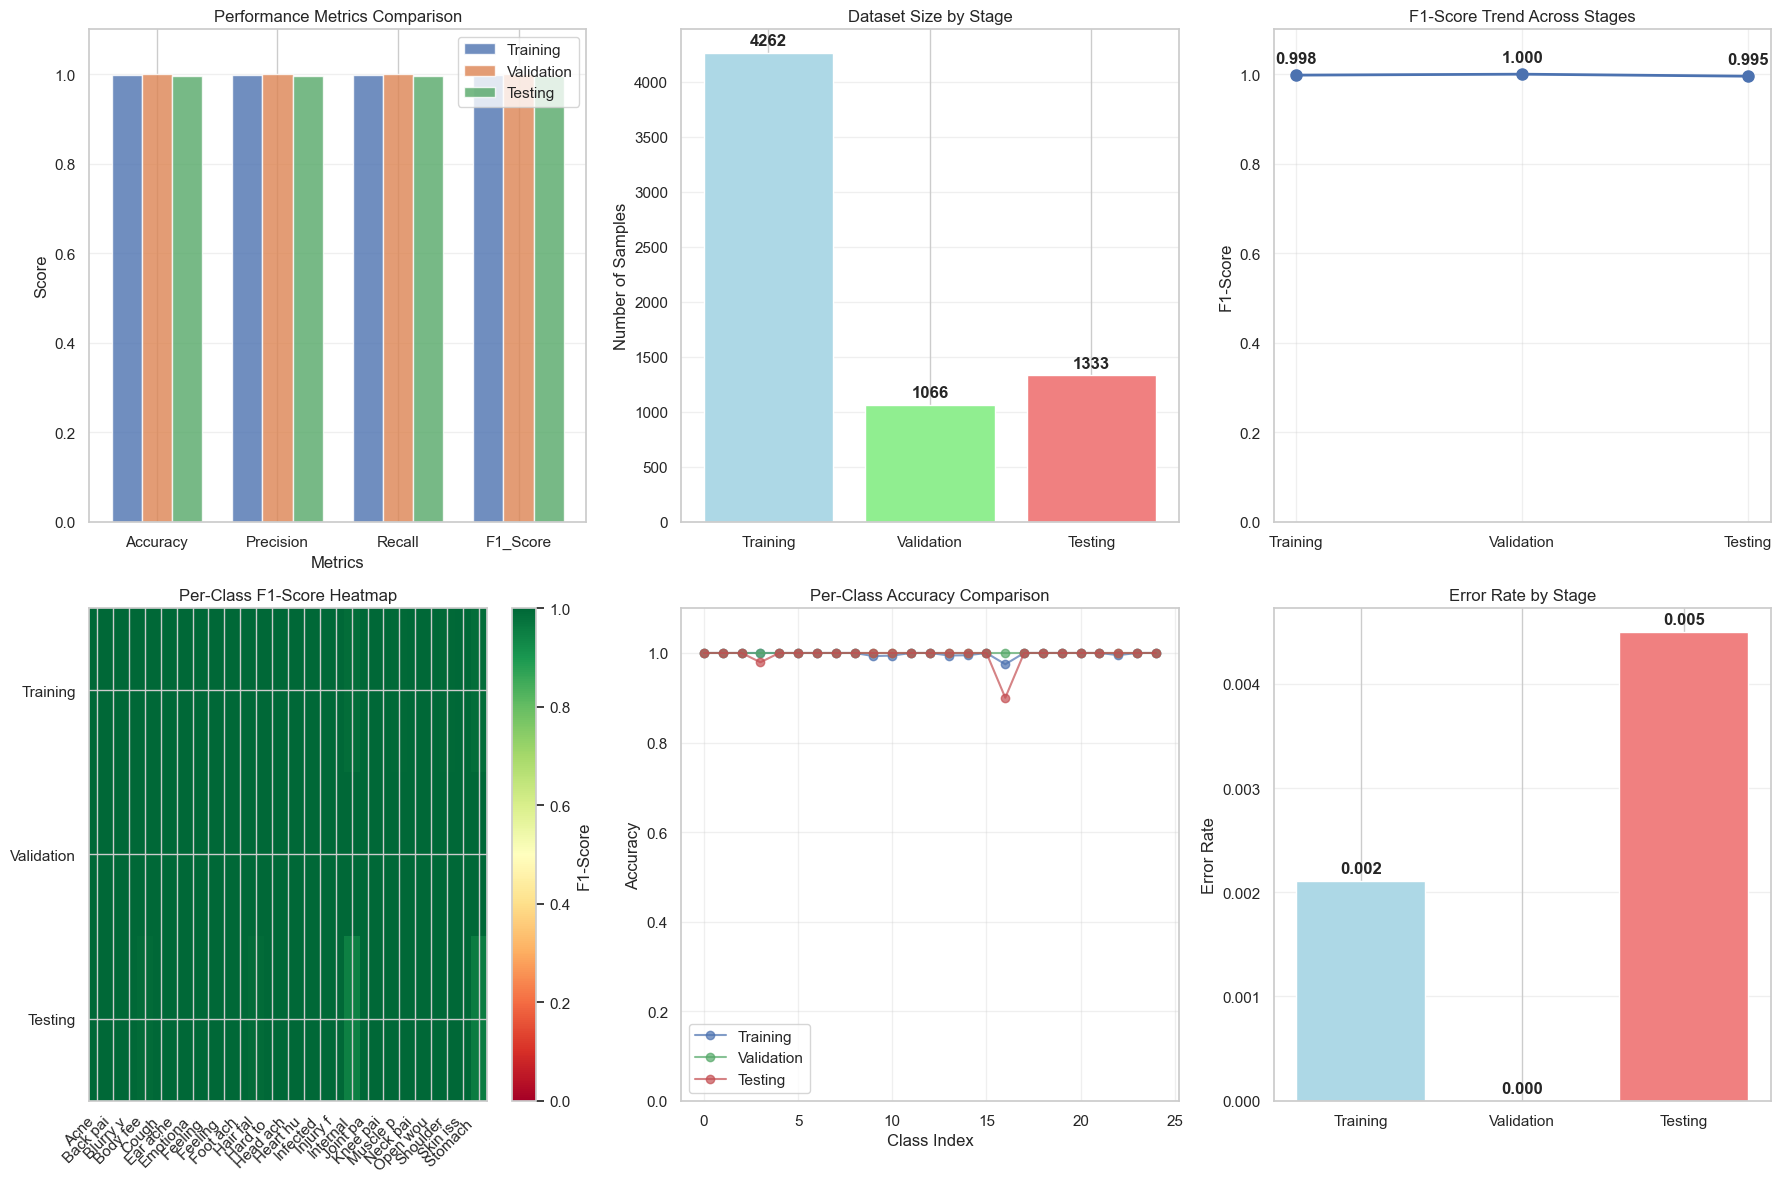


COMPREHENSIVE EVALUATION SUMMARY REPORT

MODEL: Support Vector Machine
EVALUATION DATE: 2025-06-02 15:25:37
TOTAL DATASET SIZE: 13322

STAGE-WISE PERFORMANCE:
------------------------------
    TRAINING: Acc=0.9979, Prec=0.9979, Rec=0.9979, F1=0.9979
  VALIDATION: Acc=1.0000, Prec=1.0000, Rec=1.0000, F1=1.0000
     TESTING: Acc=0.9955, Prec=0.9958, Rec=0.9955, F1=0.9955

MODEL STABILITY:
--------------------
Performance Variance (F1): 0.0018
Best Stage: Validation
Worst Stage: Testing

RECOMMENDATIONS:
--------------------
✅ Model shows good performance across all stages.
✅ Model shows consistent performance across stages.



In [179]:
# Comprehensive Stage Comparison Analysis
print(f"\n{'='*80}")
print(f"COMPREHENSIVE STAGE COMPARISON ANALYSIS")
print(f"{'='*80}")

# Create comparison table for all stages
comparison_df = pd.DataFrame({
    'Stage': ['Training', 'Validation', 'Testing'],
    'Accuracy': [results['training']['accuracy'], results['validation']['accuracy'], results['testing']['accuracy']],
    'Precision': [results['training']['precision'], results['validation']['precision'], results['testing']['precision']],
    'Recall': [results['training']['recall'], results['validation']['recall'], results['testing']['recall']],
    'F1_Score': [results['training']['f1_score'], results['validation']['f1_score'], results['testing']['f1_score']],
    'Dataset_Size': [len(y_train_eval), len(y_val_eval), len(y_test_eval)]
}).round(4)

print("\nPERFORMANCE COMPARISON ACROSS STAGES:")
print("-" * 50)
print(comparison_df.to_string(index=False))

# Calculate performance differences
training_acc = results['training']['accuracy']
validation_acc = results['validation']['accuracy']
testing_acc = results['testing']['accuracy']

val_train_diff = validation_acc - training_acc
test_train_diff = testing_acc - training_acc
test_val_diff = testing_acc - validation_acc

print(f"\nPERFORMANCE DIFFERENCES:")
print("-" * 25)
print(f"Validation vs Training: {val_train_diff:+.4f}")
print(f"Testing vs Training: {test_train_diff:+.4f}")
print(f"Testing vs Validation: {test_val_diff:+.4f}")

# Overfitting/Underfitting Analysis
if abs(val_train_diff) < 0.05 and abs(test_train_diff) < 0.05:
    fitting_status = "Well-fitted: Good generalization across all stages"
elif training_acc > validation_acc + 0.05 or training_acc > testing_acc + 0.05:
    fitting_status = "Potential Overfitting: Training performance significantly higher"
elif training_acc < 0.6:
    fitting_status = "Potential Underfitting: Low performance across all stages"
else:
    fitting_status = "Acceptable fitting: Minor performance variations"

print(f"\nMODEL FITTING ANALYSIS:")
print("-" * 25)
print(f"Status: {fitting_status}")

# Create comprehensive visualization comparing all stages
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Overall Metrics Comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1_Score']
stages = ['Training', 'Validation', 'Testing']
x = np.arange(len(metrics))
width = 0.25

for i, stage in enumerate(stages):
    values = [comparison_df[comparison_df['Stage'] == stage][metric].values[0] for metric in metrics]
    axes[0, 0].bar(x + i*width, values, width, label=stage, alpha=0.8)

axes[0, 0].set_xlabel('Metrics')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_title('Performance Metrics Comparison')
axes[0, 0].set_xticks(x + width)
axes[0, 0].set_xticklabels(metrics)
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].set_ylim(0, 1.1)

# 2. Dataset Size Comparison
axes[0, 1].bar(stages, comparison_df['Dataset_Size'], color=['lightblue', 'lightgreen', 'lightcoral'])
axes[0, 1].set_ylabel('Number of Samples')
axes[0, 1].set_title('Dataset Size by Stage')
axes[0, 1].grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(comparison_df['Dataset_Size']):
    axes[0, 1].text(i, v + max(comparison_df['Dataset_Size'])*0.01, str(int(v)), 
                    ha='center', va='bottom', fontweight='bold')

# 3. Performance Trend Line
f1_scores = [results['training']['f1_score'], results['validation']['f1_score'], results['testing']['f1_score']]
axes[0, 2].plot(stages, f1_scores, 'bo-', linewidth=2, markersize=8)
axes[0, 2].set_ylabel('F1-Score')
axes[0, 2].set_title('F1-Score Trend Across Stages')
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].set_ylim(0, 1.1)

# Add value labels
for i, v in enumerate(f1_scores):
    axes[0, 2].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# 4. Per-Class Performance Heatmap (F1-scores)
# Extract per-class F1-scores for each stage
training_f1_per_class = results['training']['performance_df']['F1_Score'][:-2].values  # Exclude avg rows
validation_f1_per_class = results['validation']['performance_df']['F1_Score'][:-2].values
testing_f1_per_class = results['testing']['performance_df']['F1_Score'][:-2].values

f1_heatmap_data = np.array([training_f1_per_class, validation_f1_per_class, testing_f1_per_class])

im = axes[1, 0].imshow(f1_heatmap_data, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
axes[1, 0].set_xticks(range(len(class_names)))
axes[1, 0].set_xticklabels([name[:8] for name in class_names], rotation=45, ha='right')
axes[1, 0].set_yticks(range(3))
axes[1, 0].set_yticklabels(['Training', 'Validation', 'Testing'])
axes[1, 0].set_title('Per-Class F1-Score Heatmap')
plt.colorbar(im, ax=axes[1, 0], label='F1-Score')

# 5. Confusion Matrix Comparison (Accuracy per class)
training_acc_per_class = results['training']['performance_df']['Accuracy'][:-2].values
validation_acc_per_class = results['validation']['performance_df']['Accuracy'][:-2].values
testing_acc_per_class = results['testing']['performance_df']['Accuracy'][:-2].values

axes[1, 1].plot(range(len(class_names)), training_acc_per_class, 'bo-', label='Training', alpha=0.7)
axes[1, 1].plot(range(len(class_names)), validation_acc_per_class, 'go-', label='Validation', alpha=0.7)
axes[1, 1].plot(range(len(class_names)), testing_acc_per_class, 'ro-', label='Testing', alpha=0.7)
axes[1, 1].set_xlabel('Class Index')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('Per-Class Accuracy Comparison')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_ylim(0, 1.1)

# 6. Error Analysis
error_rates = [1 - results['training']['accuracy'], 1 - results['validation']['accuracy'], 1 - results['testing']['accuracy']]
axes[1, 2].bar(stages, error_rates, color=['lightblue', 'lightgreen', 'lightcoral'])
axes[1, 2].set_ylabel('Error Rate')
axes[1, 2].set_title('Error Rate by Stage')
axes[1, 2].grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(error_rates):
    axes[1, 2].text(i, v + max(error_rates)*0.01, f'{v:.3f}', 
                    ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Generate comprehensive summary report
print(f"\n{'='*80}")
print(f"COMPREHENSIVE EVALUATION SUMMARY REPORT")
print(f"{'='*80}")

print(f"\nMODEL: {best_model_name}")
print(f"EVALUATION DATE: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"TOTAL DATASET SIZE: {len(X) + len(y)}")

print(f"\nSTAGE-WISE PERFORMANCE:")
print("-" * 30)
for stage_name, stage_results in results.items():
    print(f"{stage_name.upper():>12}: Acc={stage_results['accuracy']:.4f}, "
          f"Prec={stage_results['precision']:.4f}, "
          f"Rec={stage_results['recall']:.4f}, "
          f"F1={stage_results['f1_score']:.4f}")

print(f"\nMODEL STABILITY:")
print("-" * 20)
print(f"Performance Variance (F1): {np.std(f1_scores):.4f}")
print(f"Best Stage: {stages[np.argmax(f1_scores)]}")
print(f"Worst Stage: {stages[np.argmin(f1_scores)]}")

print(f"\nRECOMMENDATIONS:")
print("-" * 20)
if abs(val_train_diff) > 0.1:
    print("⚠️  Large training-validation gap detected. Consider regularization.")
if abs(test_val_diff) > 0.05:
    print("⚠️  Validation-test performance gap. Review validation strategy.")
if min(f1_scores) > 0.7:
    print("✅ Model shows good performance across all stages.")
if np.std(f1_scores) < 0.02:
    print("✅ Model shows consistent performance across stages.")

print(f"\n{'='*80}")

## 8. Research Hypothesis Evaluation

Based on the comprehensive evaluation, determine whether the model performance supports the research hypothesis.

RESEARCH HYPOTHESIS EVALUATION
Research Question: What is the effectiveness of the NLP algorithm in classifying
patient symptoms from text data on the population level?

Performance Threshold for Clinical Decision Support: 0.7
Selected Model: Support Vector Machine

FINAL MODEL PERFORMANCE:
-------------------------
Test Accuracy:  0.9955
Test Precision: 0.9958
Test Recall:    0.9955
Test F1-Score:  0.9955

PERFORMANCE THRESHOLD ANALYSIS:
-----------------------------------
Accuracy ≥ 0.7: ✓ (0.9955)
Precision ≥ 0.7: ✓ (0.9958)
Recall ≥ 0.7: ✓ (0.9955)
F1-Score ≥ 0.7: ✓ (0.9955)

HYPOTHESIS CONCLUSION:
Status: ACCEPTED
Conclusion: H1a: Text analysis of patient symptoms results in precision and recall sufficient for provider decision support.

ADDITIONAL INSIGHTS:
--------------------
Cross-validation stability: Stable
Model confidence: 0.0021 standard deviation
Best performing class: Stomach ache (1.000 accuracy)
Most challenging class: Internal pain (0.900 accuracy)


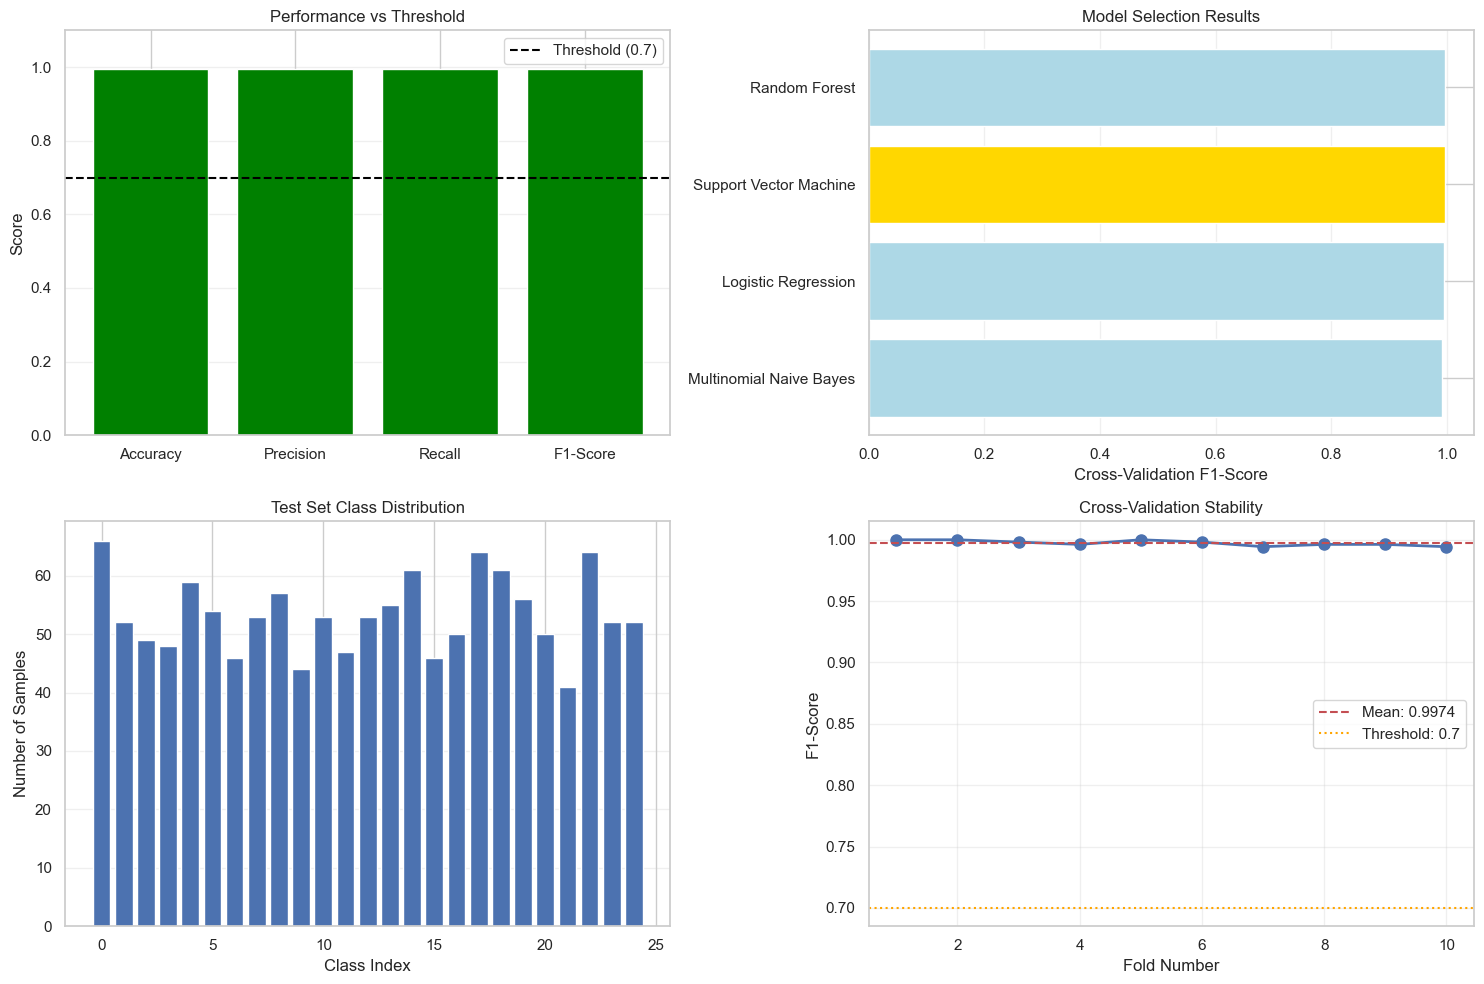


FINAL RESEARCH OUTCOME: ACCEPTED


In [180]:
# Research hypothesis evaluation
performance_threshold = 0.7  # Minimum acceptable performance for clinical decision support

print(f"RESEARCH HYPOTHESIS EVALUATION")
print("="*50)
print(f"Research Question: What is the effectiveness of the NLP algorithm in classifying")
print(f"patient symptoms from text data on the population level?")
print()

print(f"Performance Threshold for Clinical Decision Support: {performance_threshold}")
print(f"Selected Model: {best_model_name}")
print()

print(f"FINAL MODEL PERFORMANCE:")
print("-" * 25)
print(f"Test Accuracy:  {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f}")
print(f"Test F1-Score:  {test_f1:.4f}")

# Determine hypothesis outcome
accuracy_sufficient = test_accuracy >= performance_threshold
precision_sufficient = test_precision >= performance_threshold
recall_sufficient = test_recall >= performance_threshold
f1_sufficient = test_f1 >= performance_threshold

overall_sufficient = all([accuracy_sufficient, precision_sufficient, 
                         recall_sufficient, f1_sufficient])

print(f"\nPERFORMANCE THRESHOLD ANALYSIS:")
print("-" * 35)
print(f"Accuracy ≥ {performance_threshold}: {'✓' if accuracy_sufficient else '✗'} ({test_accuracy:.4f})")
print(f"Precision ≥ {performance_threshold}: {'✓' if precision_sufficient else '✗'} ({test_precision:.4f})")
print(f"Recall ≥ {performance_threshold}: {'✓' if recall_sufficient else '✗'} ({test_recall:.4f})")
print(f"F1-Score ≥ {performance_threshold}: {'✓' if f1_sufficient else '✗'} ({test_f1:.4f})")

print(f"\nHYPOTHESIS CONCLUSION:")
print("="*25)

if overall_sufficient:
    conclusion = "H1a: Text analysis of patient symptoms results in precision and recall sufficient for provider decision support."
    conclusion_status = "ACCEPTED"
else:
    conclusion = "H10: Text analysis of patient symptoms results in insufficient precision and recall for provider decision support."
    conclusion_status = "REJECTED (H10 accepted)"

print(f"Status: {conclusion_status}")
print(f"Conclusion: {conclusion}")

# Additional analysis
print(f"\nADDITIONAL INSIGHTS:")
print("-" * 20)
print(f"Cross-validation stability: {cv_stability}")
print(f"Model confidence: {extended_scores.std():.4f} standard deviation")
print(f"Best performing class: {class_names[best_classes[-1]]} ({per_class_accuracy[best_classes[-1]]:.3f} accuracy)")
print(f"Most challenging class: {class_names[worst_classes[0]]} ({per_class_accuracy[worst_classes[0]]:.3f} accuracy)")

# Create final summary visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Threshold comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [test_accuracy, test_precision, test_recall, test_f1]
colors = ['green' if v >= performance_threshold else 'red' for v in values]

bars = ax1.bar(metrics, values, color=colors)
ax1.axhline(y=performance_threshold, color='black', linestyle='--', 
           label=f'Threshold ({performance_threshold})')
ax1.set_title('Performance vs Threshold')
ax1.set_ylabel('Score')
ax1.set_ylim(0, 1.1)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Model comparison (from earlier CV results)
models_cv = list(cv_results.keys())
scores_cv = [cv_results[model]['mean'] for model in models_cv]
colors_models = ['gold' if model == best_model_name else 'lightblue' for model in models_cv]

ax2.barh(models_cv, scores_cv, color=colors_models)
ax2.set_xlabel('Cross-Validation F1-Score')
ax2.set_title('Model Selection Results')
ax2.grid(axis='x', alpha=0.3)

# Plot 3: Class distribution in test set
class_counts = np.bincount(y_test)
ax3.bar(range(len(class_counts)), class_counts)
ax3.set_title('Test Set Class Distribution')
ax3.set_xlabel('Class Index')
ax3.set_ylabel('Number of Samples')
ax3.grid(axis='y', alpha=0.3)

# Plot 4: Performance over CV folds
ax4.plot(range(1, 11), extended_scores, 'bo-', linewidth=2, markersize=8)
ax4.axhline(y=extended_scores.mean(), color='r', linestyle='--', 
           label=f'Mean: {extended_scores.mean():.4f}')
ax4.axhline(y=performance_threshold, color='orange', linestyle=':', 
           label=f'Threshold: {performance_threshold}')
ax4.set_title('Cross-Validation Stability')
ax4.set_xlabel('Fold Number')
ax4.set_ylabel('F1-Score')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"FINAL RESEARCH OUTCOME: {conclusion_status}")
print(f"{'='*60}")